In [1]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os

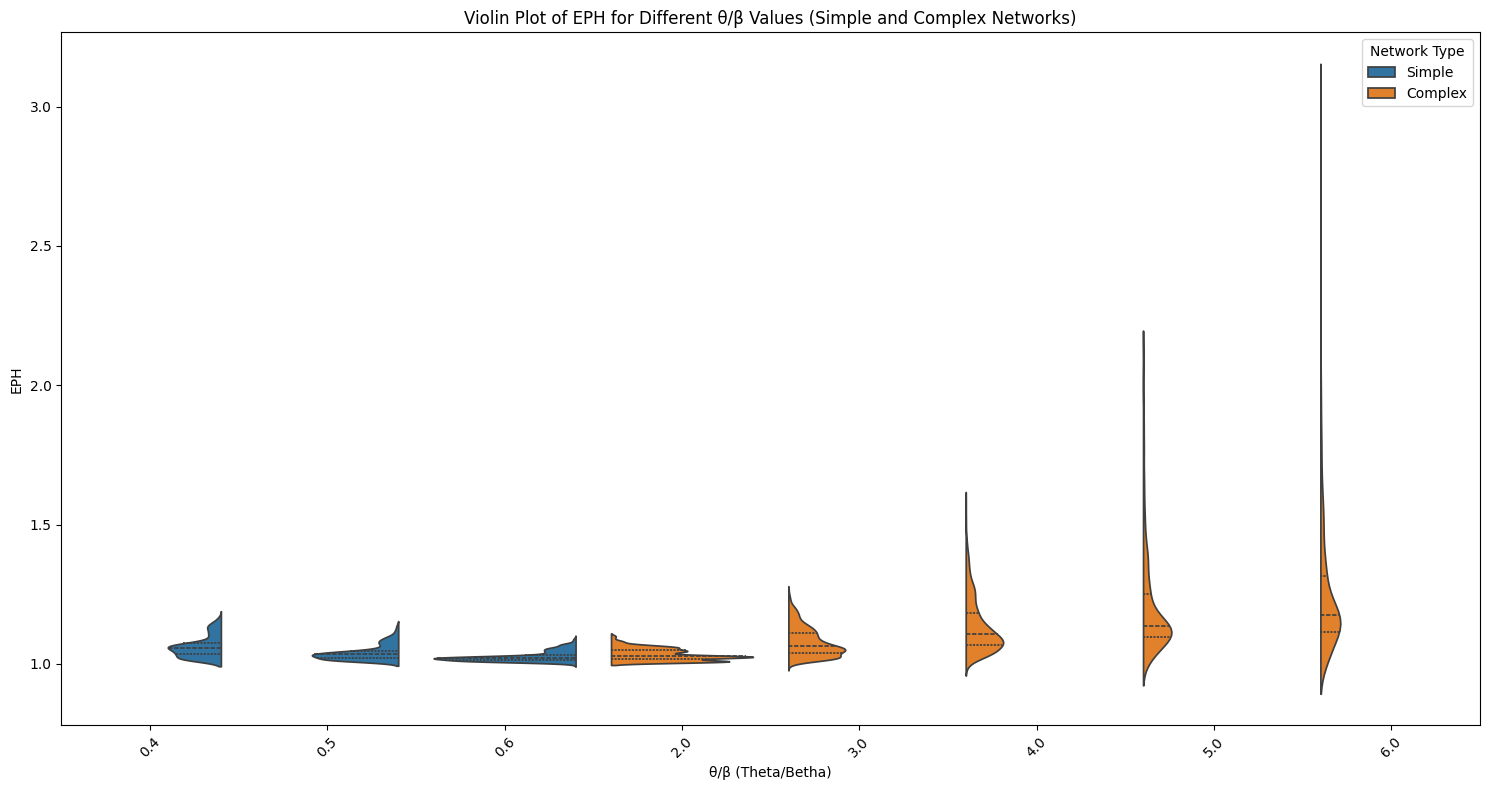

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_combined_violin_eph_distribution(network_list, network_type='combined'):
    # Prepare a combined DataFrame for both simple and complex networks
    combined_data = pd.DataFrame()
    
    for network_name in network_list:
        # Read data for complex network
        complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        complex_data['network_type'] = 'Complex'
        complex_data['network_name'] = network_name
        complex_data['x_column'] = complex_data['theta']
        
        # Read data for simple network
        simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        simple_data['network_type'] = 'Simple'
        simple_data['network_name'] = network_name
        simple_data['x_column'] = simple_data['betha']
        
        # Combine both
        combined_data = pd.concat([combined_data, complex_data, simple_data], axis=0)
    
    # Set up the figure
    plt.figure(figsize=(15, 8))
    
    # Plot violin plot
    sns.violinplot(x='x_column', y='EPH', hue='network_type', data=combined_data, split=True, inner='quartile')
    
    plt.xlabel('θ/β (Theta/Betha)')
    plt.ylabel('EPH')
    plt.title('Violin Plot of EPH for Different θ/β Values (Simple and Complex Networks)')
    plt.legend(title='Network Type')
    
    # Adjust layout
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Create base path
    base_path = "../results/unweighted_plots/violin_eph_distribution_analysis"
    
    # Ensure directory exists
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot as SVG
    plot_filename = f"{base_path}/violin_eph_distribution_combined.svg"
    plt.savefig(plot_filename, format='svg', dpi=300, bbox_inches='tight')
    
    plt.show()

# Run the analysis for a set of networks
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']

# Create violin plots for combined data of simple and complex networks
plot_combined_violin_eph_distribution(network_list)



/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/438124407.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


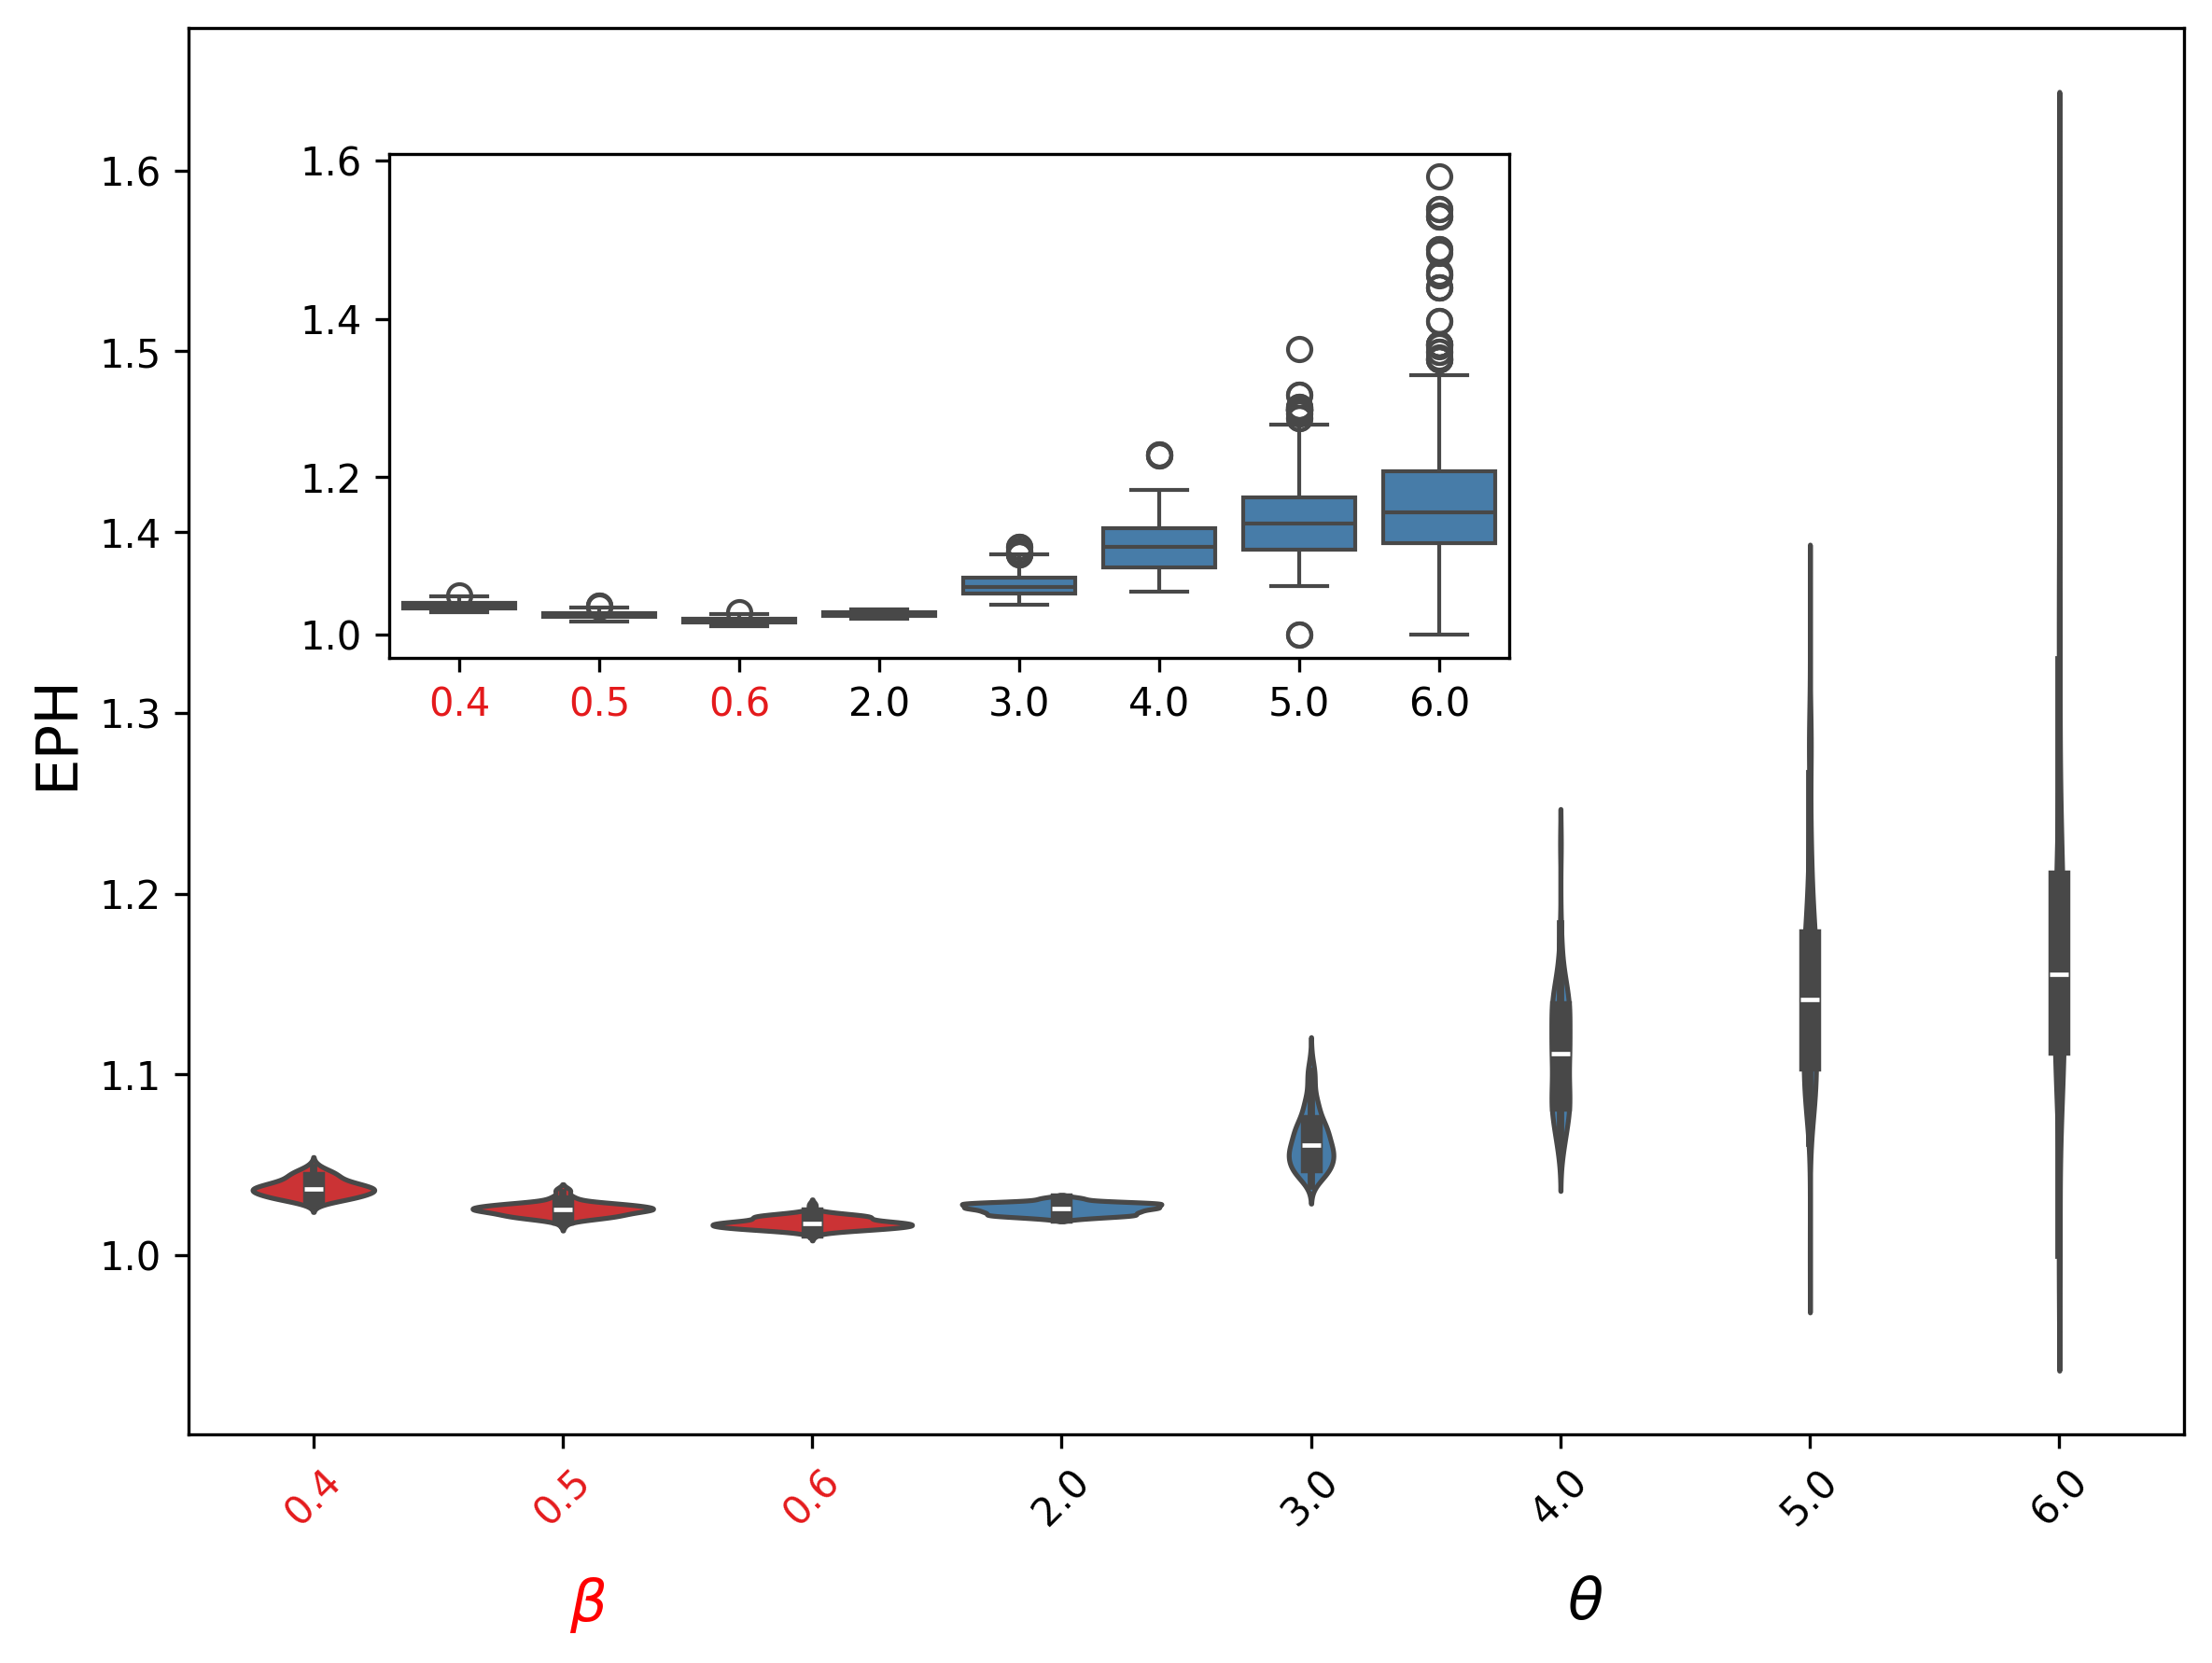

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/438124407.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


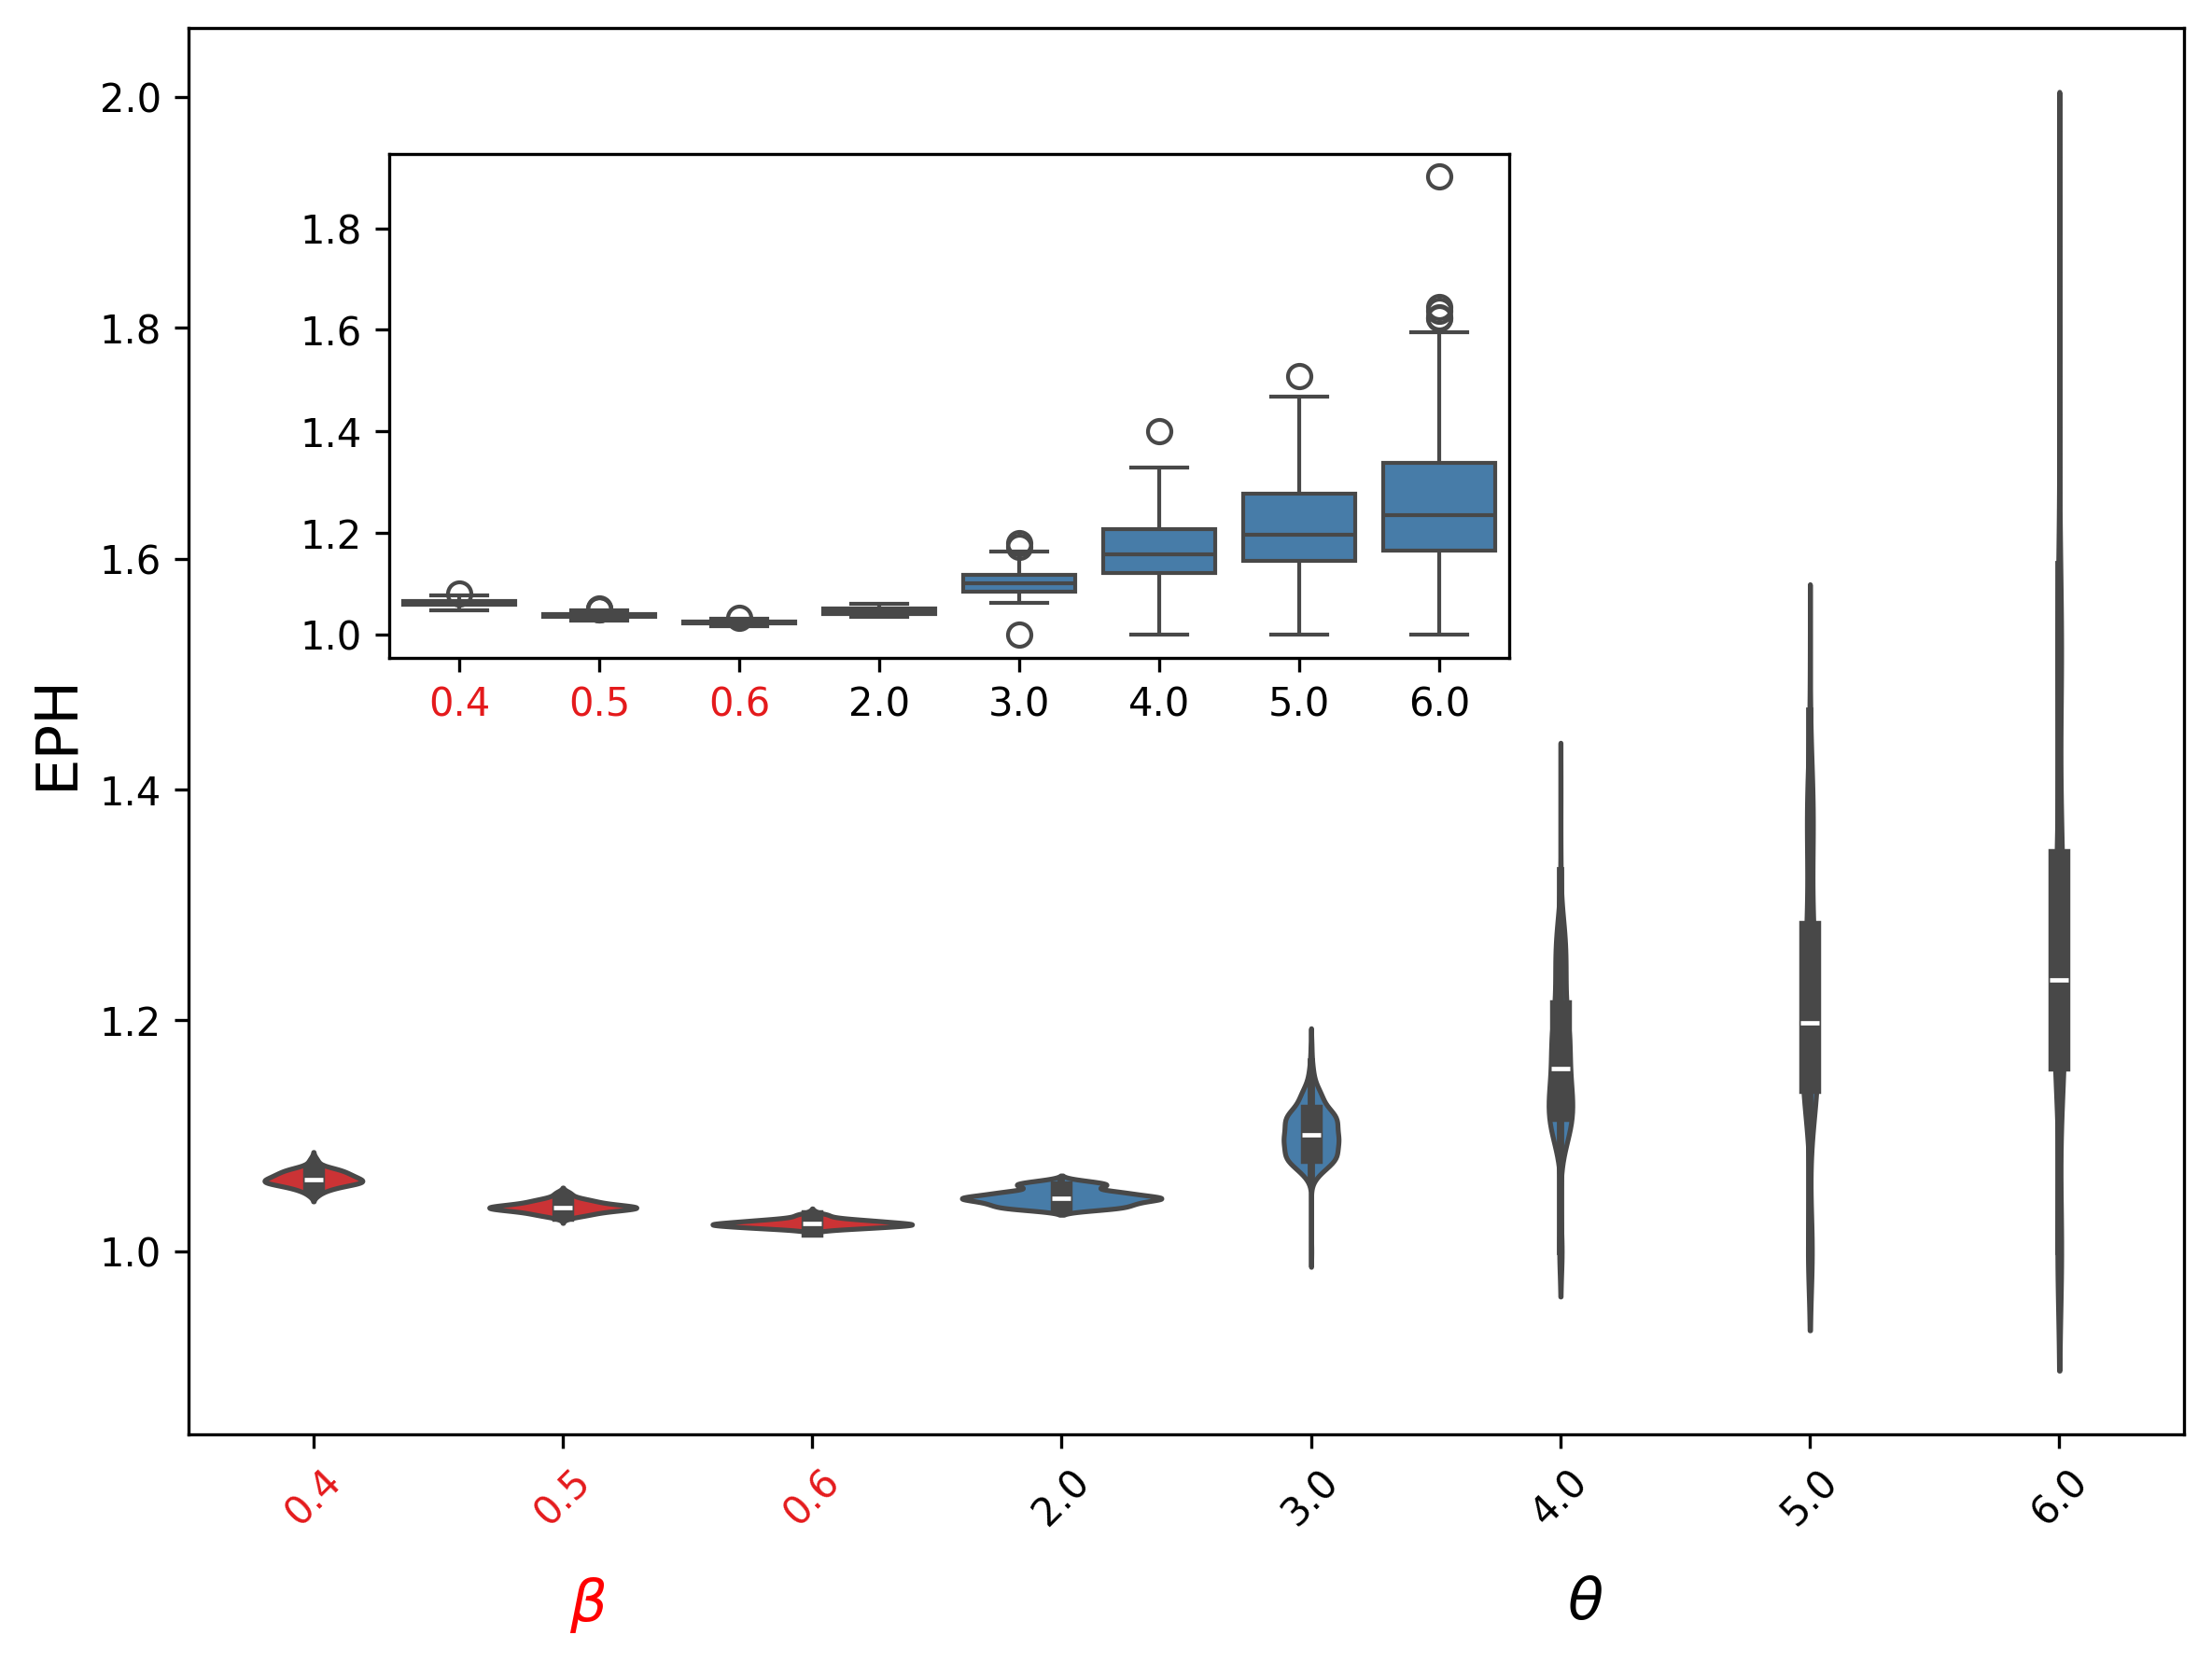

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/438124407.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


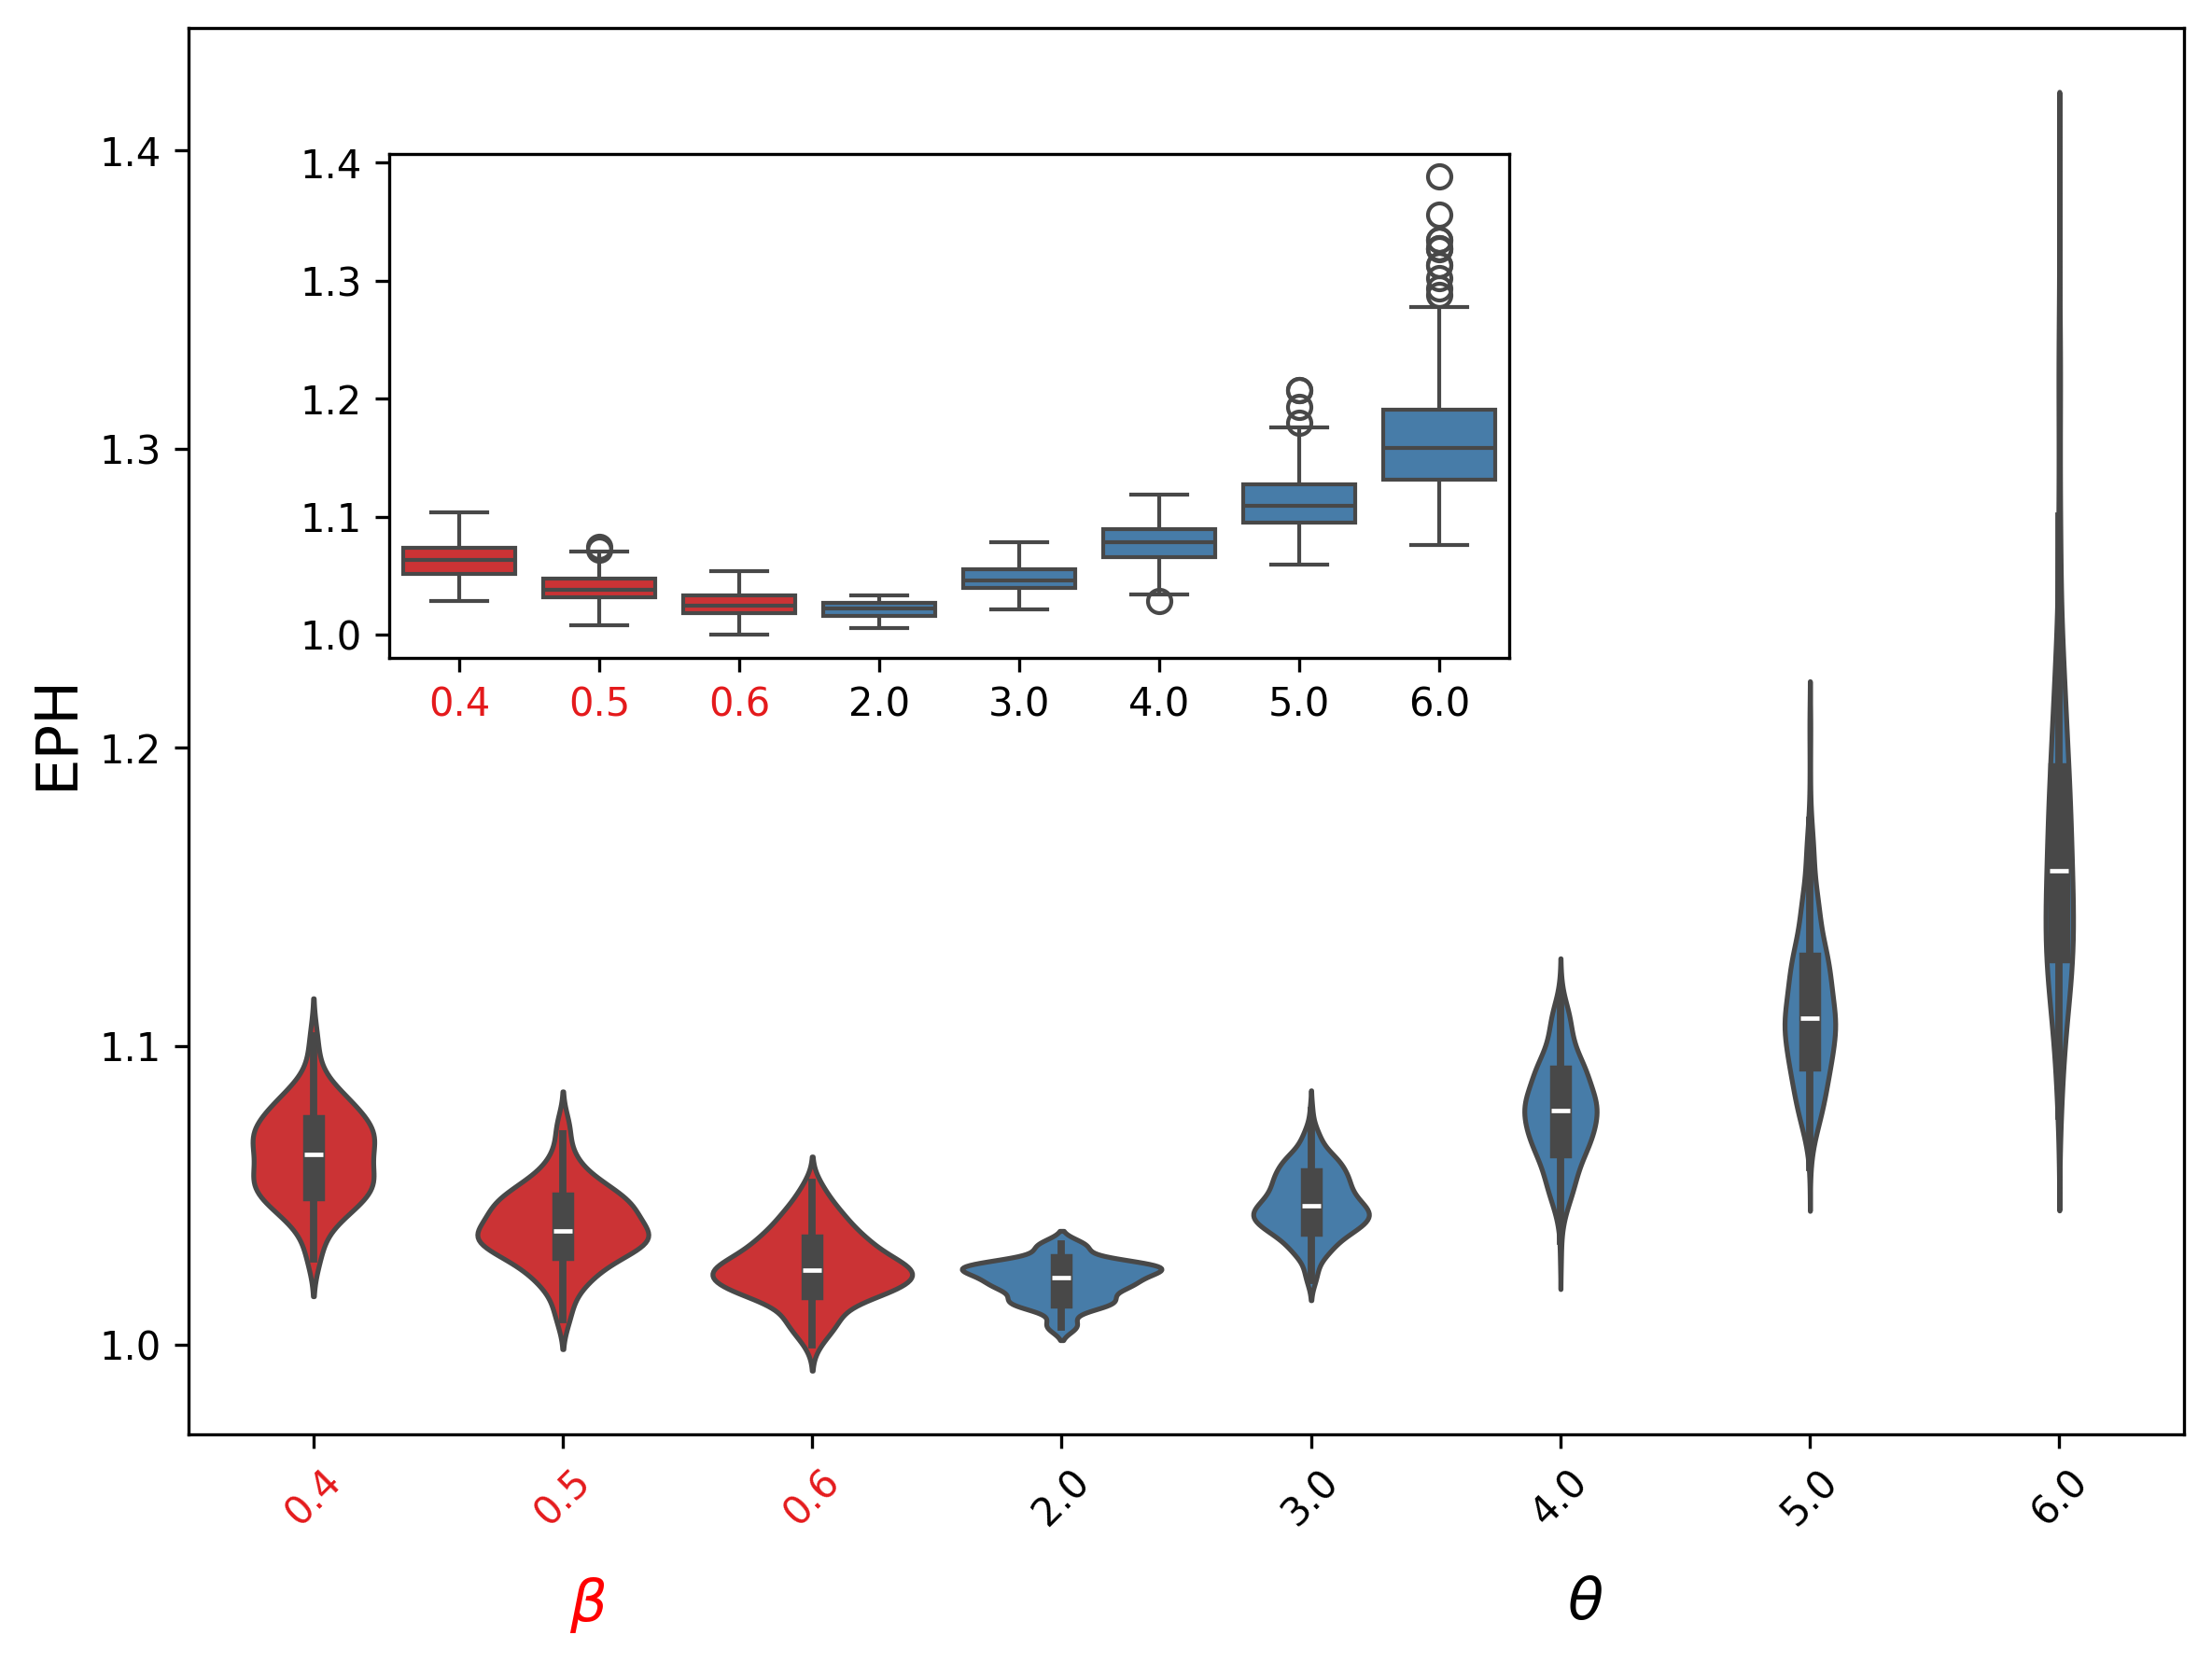

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/438124407.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


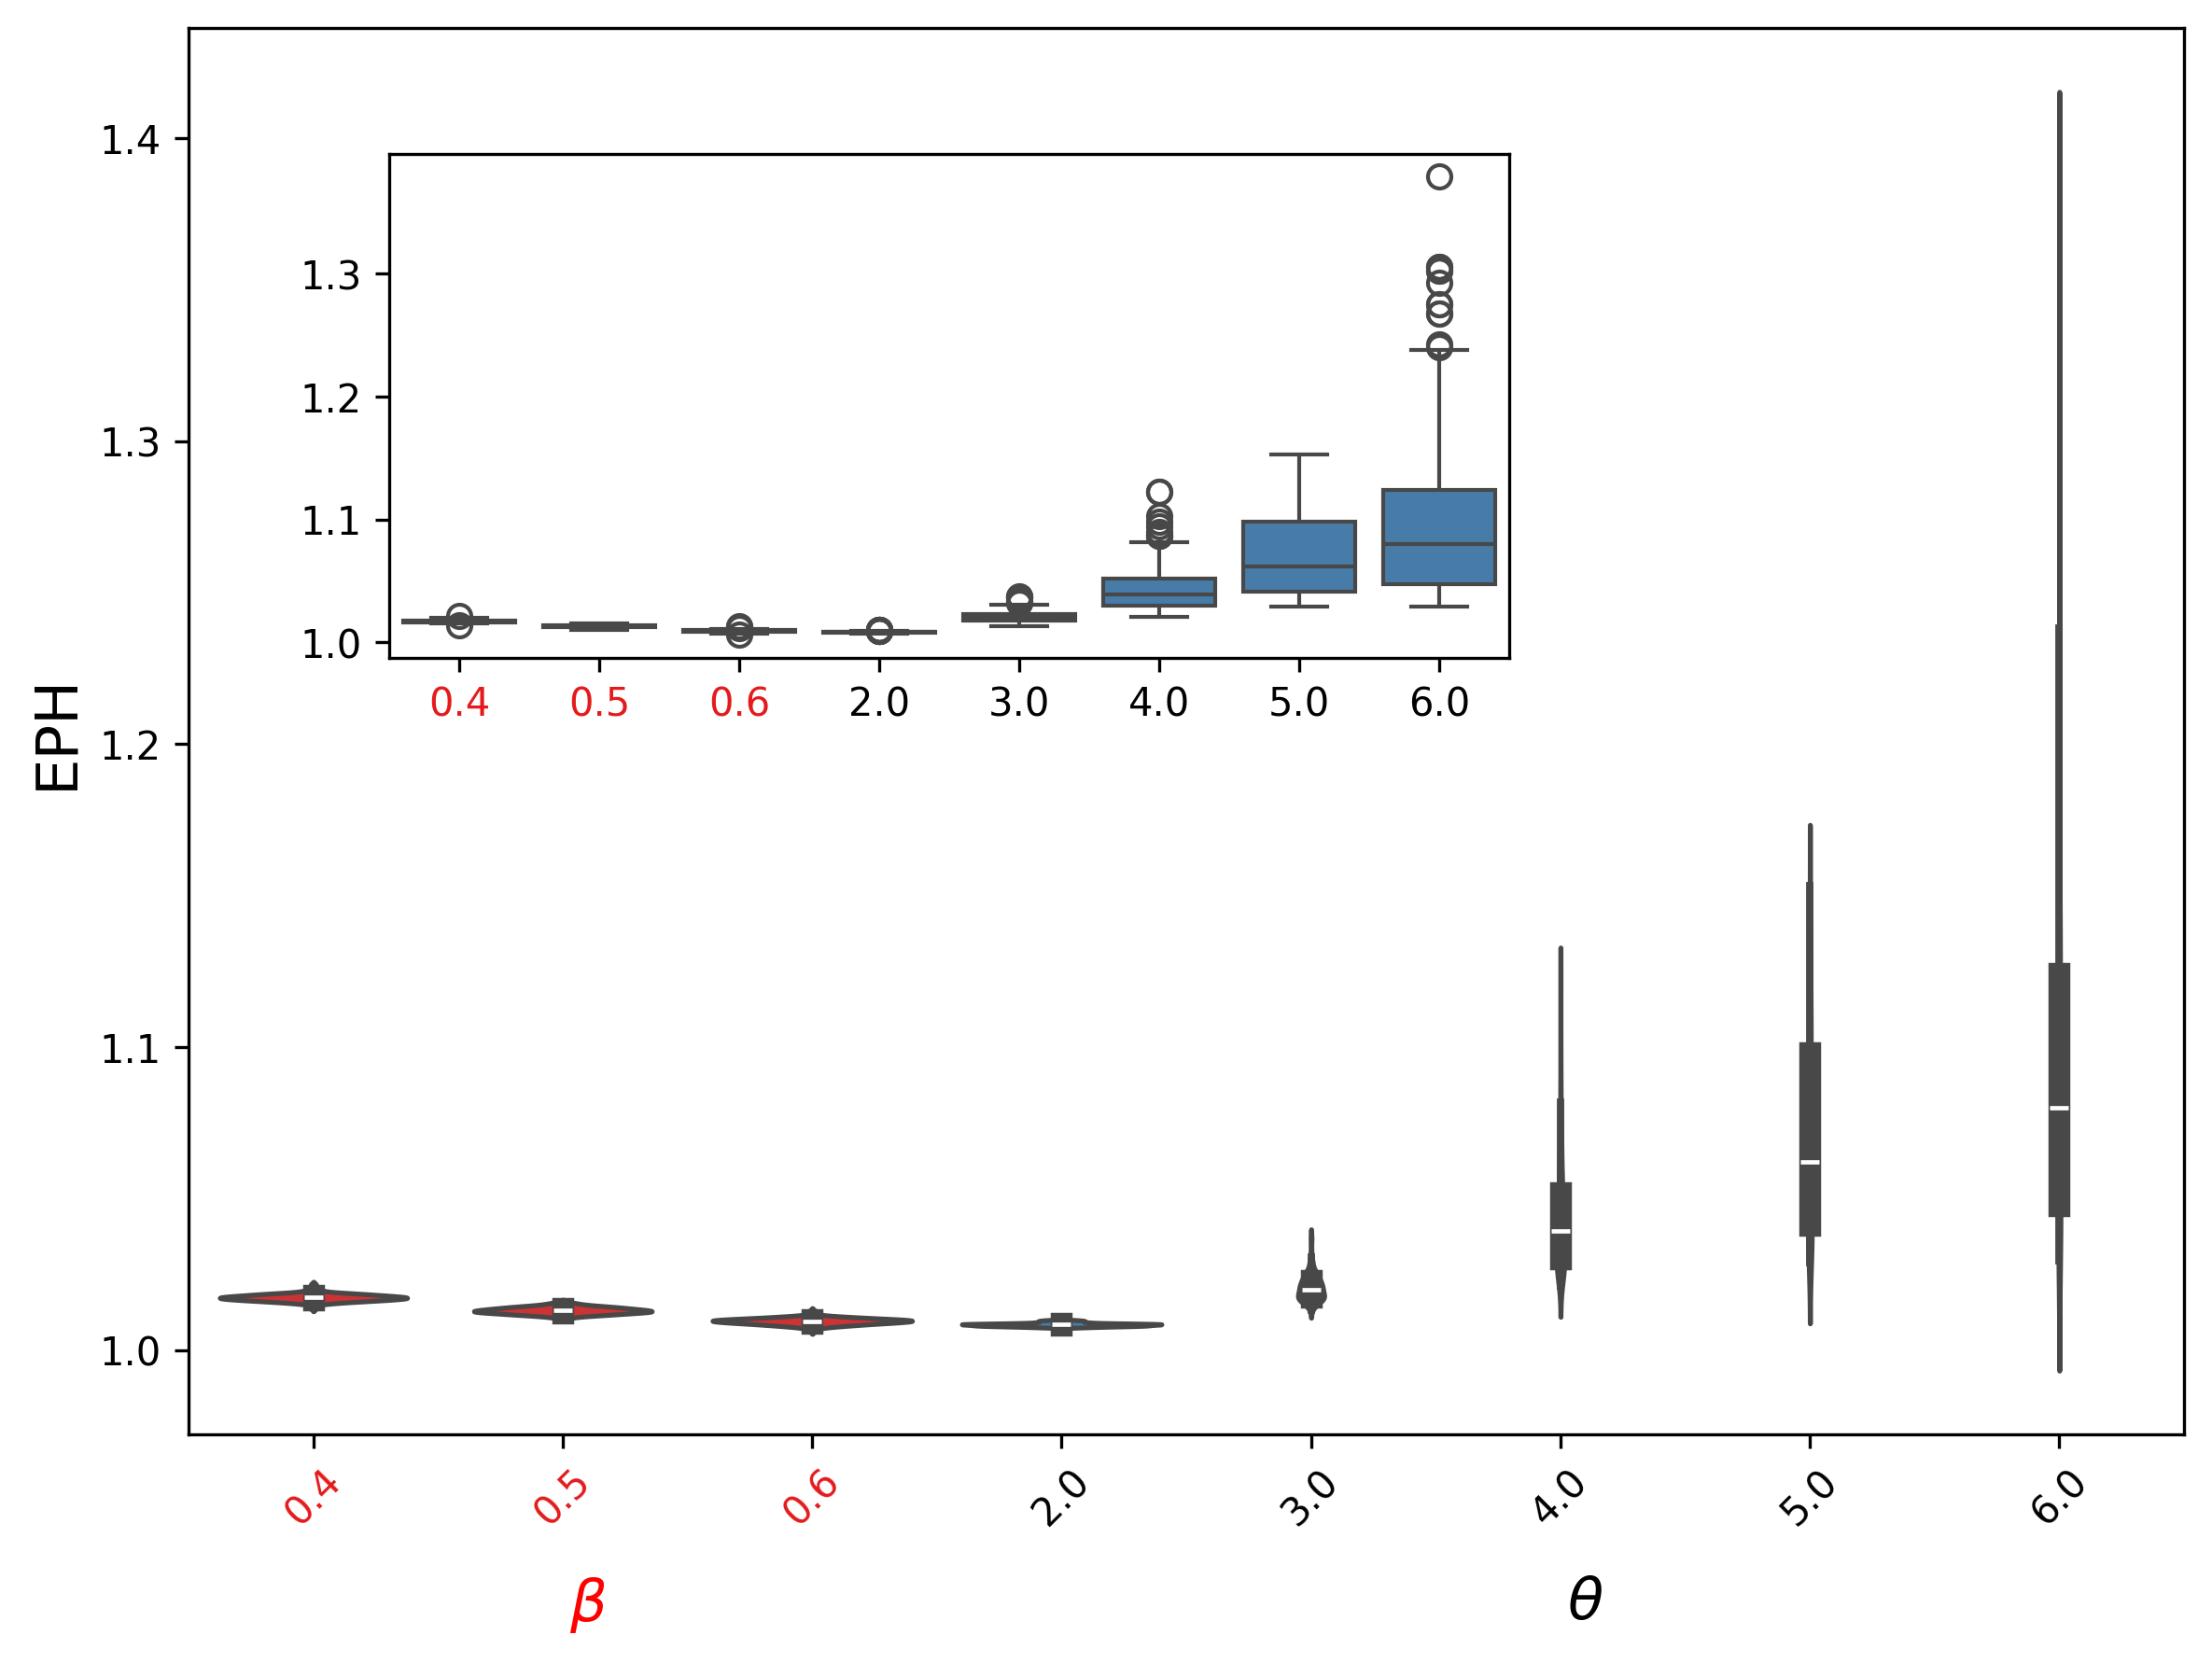

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/438124407.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


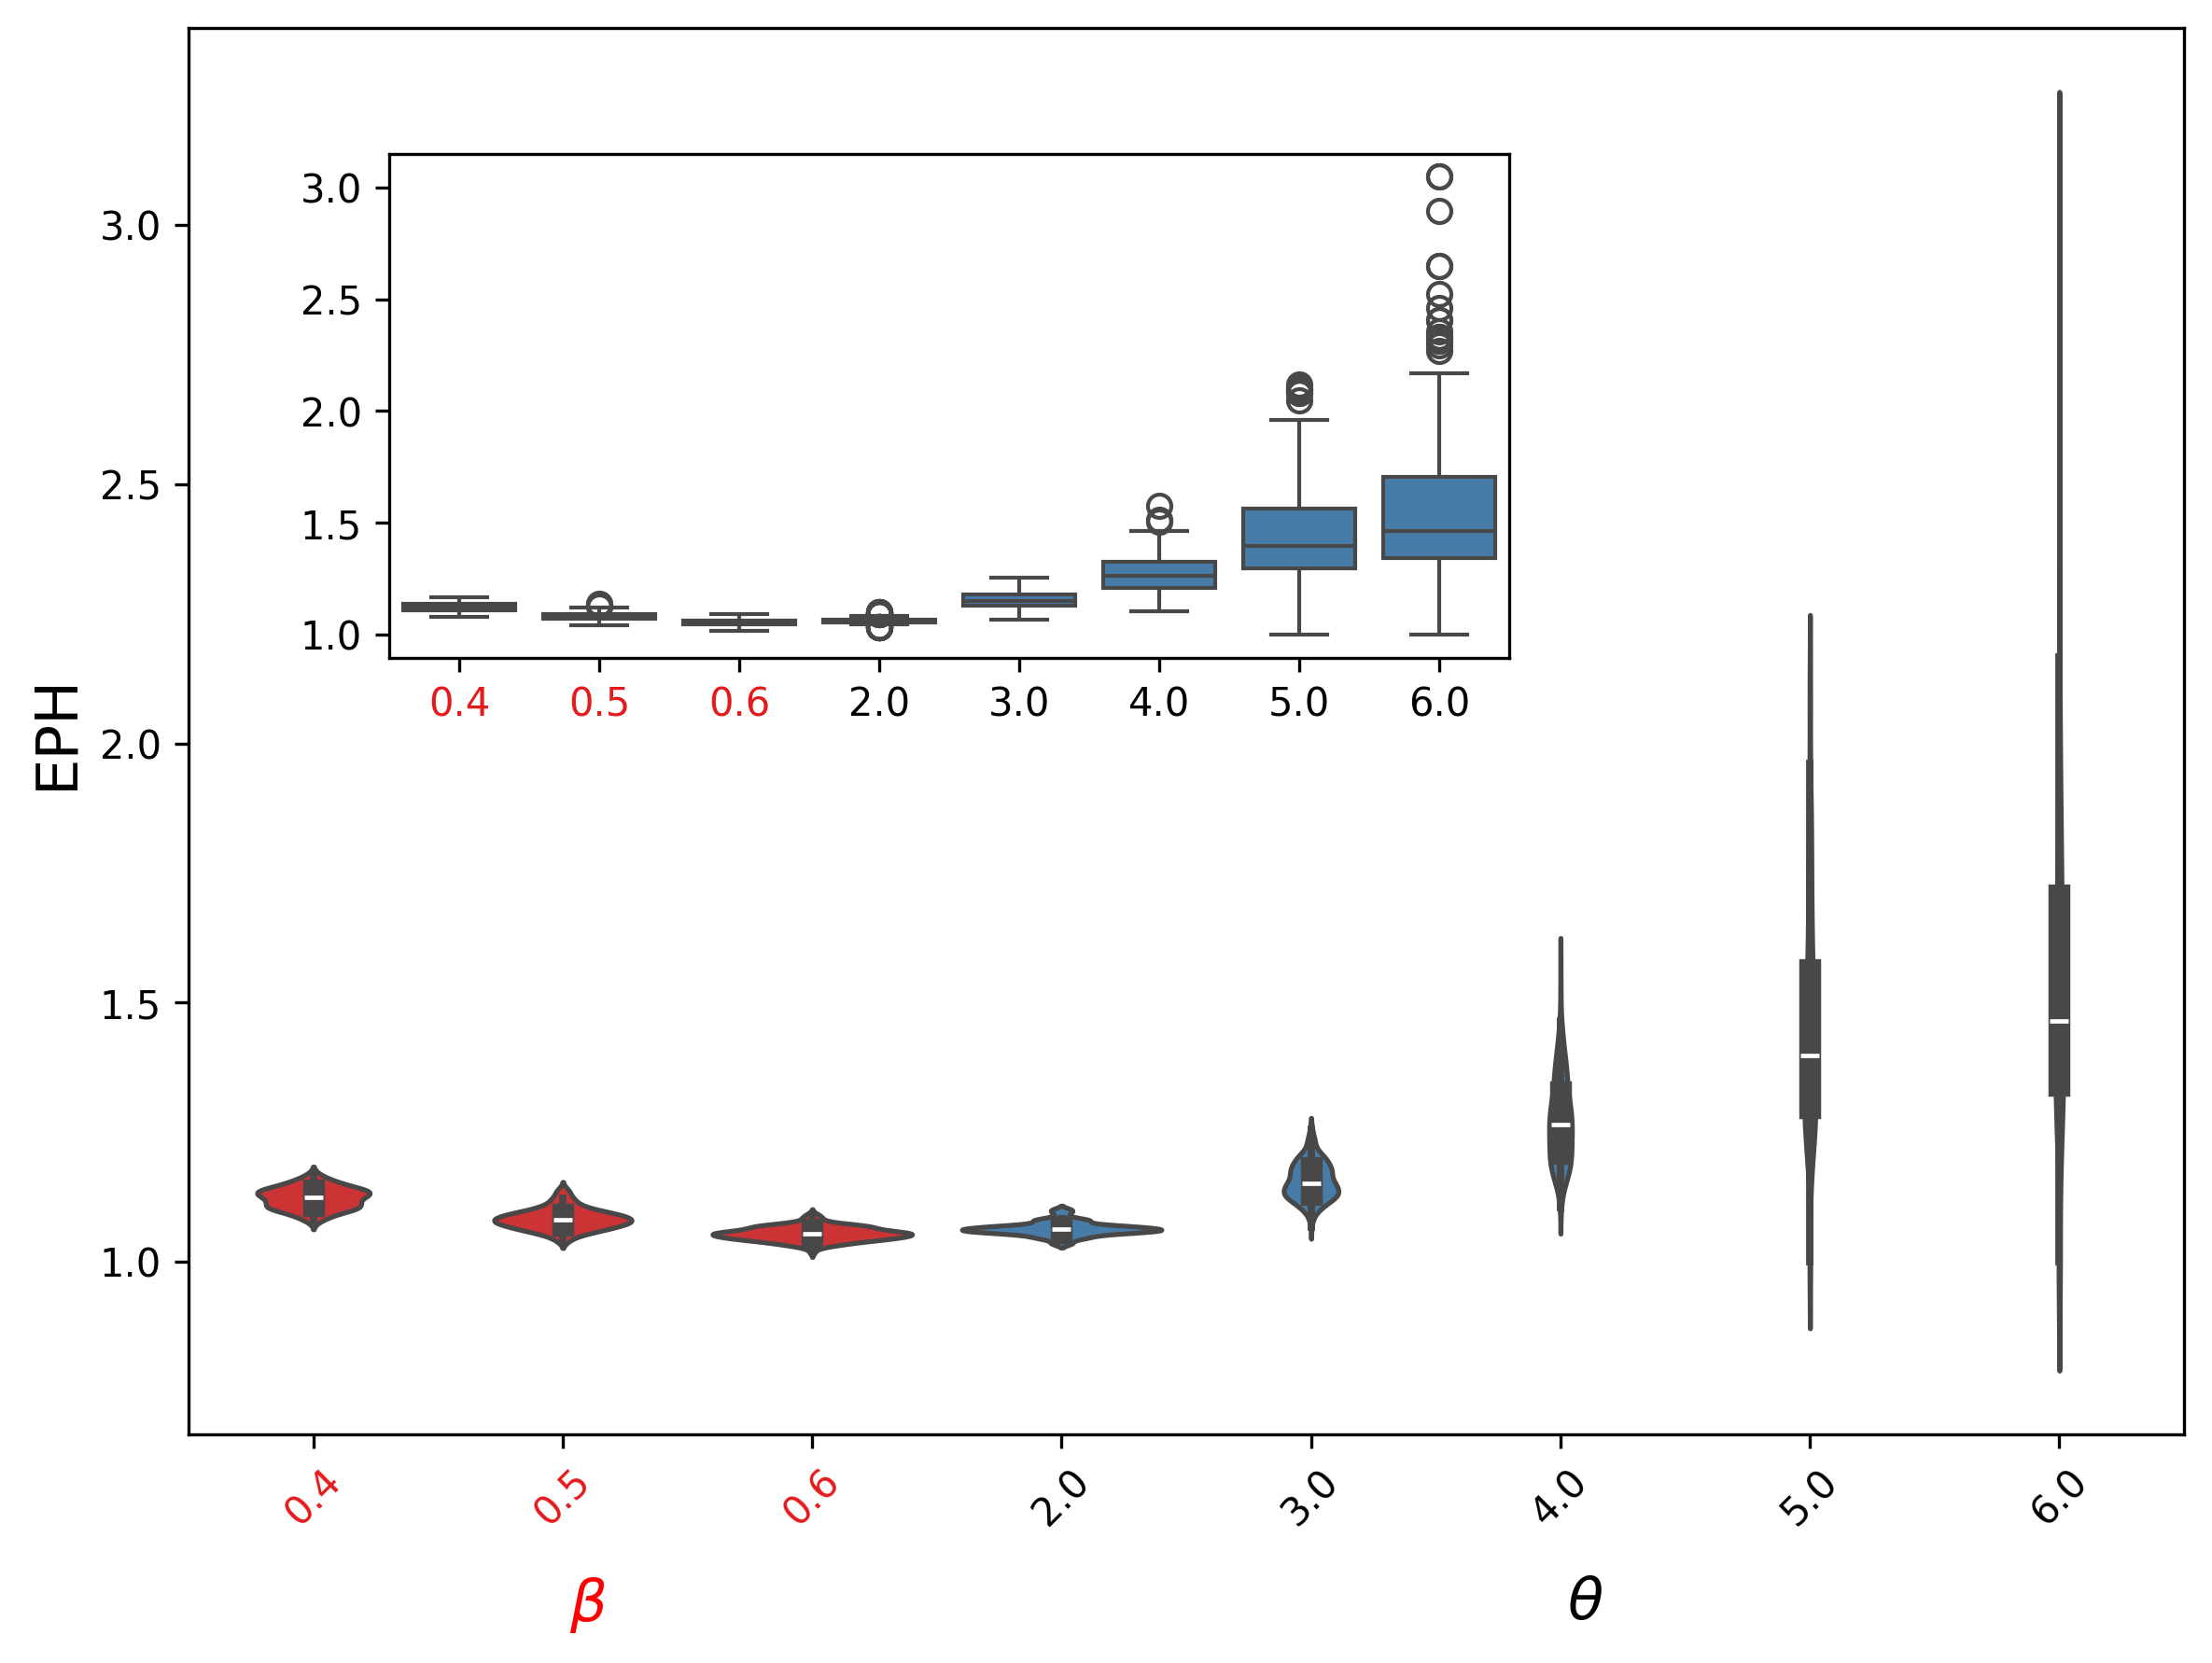

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_combined_violin_with_inset_boxplot(network_name):
    # Read data for complex network
    complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
    complex_data['network_type'] = 'Complex'
    complex_data['x_column'] = complex_data['theta']
    
    # Read data for simple network
    simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
    simple_data['network_type'] = 'Simple'
    simple_data['x_column'] = simple_data['betha']
    
    # Combine both
    combined_data = pd.concat([complex_data, simple_data], axis=0)
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    # Plot the main violin plot with specified colors for simple and complex contagion
    sns.violinplot(
        x='x_column', y='EPH', hue='network_type', data=combined_data, ax=ax, 
        palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
    )
    ax.set_ylabel('EPH',fontsize=15)
    ax.set_title(f'Violin Plot of EPH for Different θ/β Values ({network_name} Network)')
    ax.set_title('')

    ax.tick_params(axis='x', rotation=45)
    ax.legend_.remove()  # Remove legend

    # Customize x-axis label to show "β" in red and "θ" in black
    ax.set_xlabel('')
    ax.text(
        0.7, -0.1, r'$\theta$', ha='center', va='top', transform=ax.transAxes,
        fontsize=15, color='black'
    )
    ax.text(
        0.2, -0.1, r'$\beta$', ha='center', va='top', transform=ax.transAxes,
        fontsize=15, color='red'
    )

        # Customize the x-axis labels with colors for the main violin plot
    for label in ax.get_xticklabels():
        if label.get_text() in complex_data['x_column'].astype(str).unique():
            label.set_color('#377eb8')
        elif label.get_text() in simple_data['x_column'].astype(str).unique():
            label.set_color('#e41a1c')
    

    # Create an inset axis for the box plot
    inset_ax = fig.add_axes([0.18, 0.60, 0.5, 0.3])  # Adjust position and size as needed
    sns.boxplot(
        x='x_column', y='EPH', hue='network_type', data=combined_data, ax=inset_ax,
        palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
    )
    inset_ax.set_xlabel('')
    inset_ax.set_ylabel('')
    inset_ax.set_title('')
    inset_ax.legend_.remove()  # Remove legend from the inset for clarity
    
    # Customize the x-axis labels with colors for the inset box plot
    for label in inset_ax.get_xticklabels():
        if label.get_text() in complex_data['x_column'].astype(str).unique():
            label.set_color('#377eb8')
        elif label.get_text() in simple_data['x_column'].astype(str).unique():
            label.set_color('#e41a1c')
    
    # Adjust layout and save the plot
    plt.tight_layout()
    base_path = "../results/unweighted_plots/violin_with_inset_boxplot_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    plot_filename = f"{base_path}/violin_with_inset_boxplot_{network_name}.pdf"
    plt.savefig(plot_filename, format='pdf', dpi=1200, bbox_inches='tight')
    
    plt.show()

# Run the analysis for a set of networks
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']

# Create violin plots with an inset box plot for each network
for network_name in network_list:
    plot_combined_violin_with_inset_boxplot(network_name)


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/162729160.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


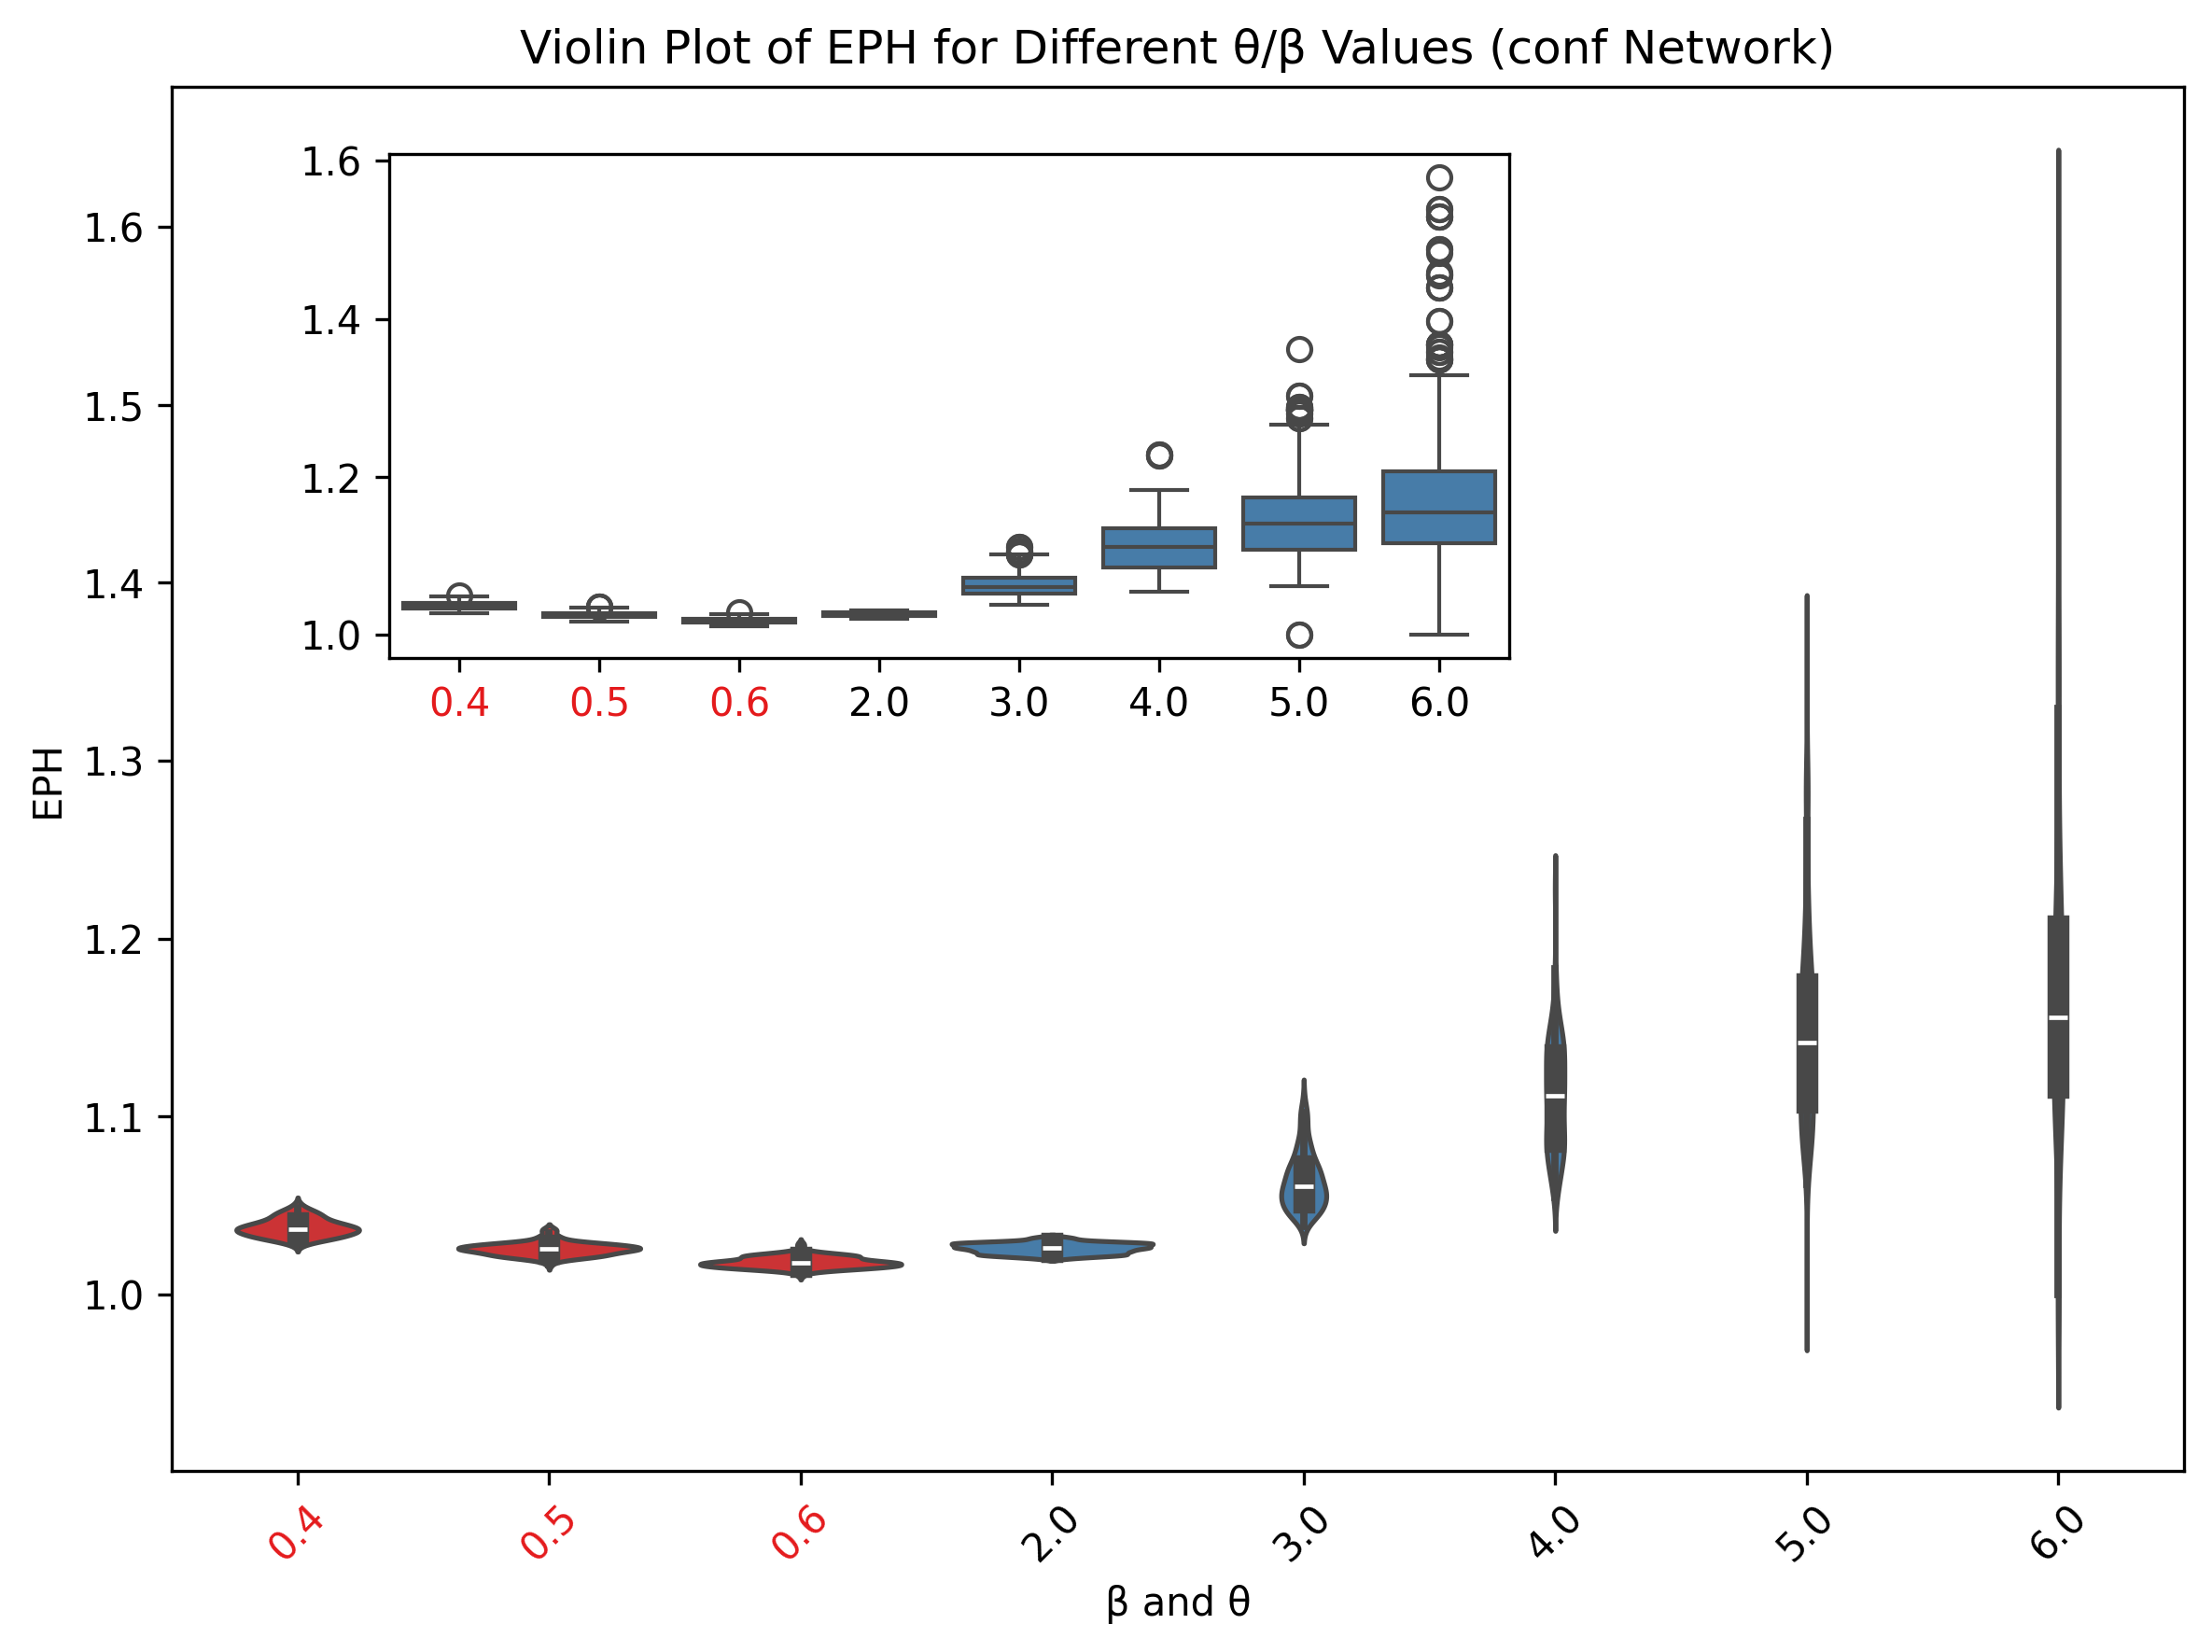

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/162729160.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


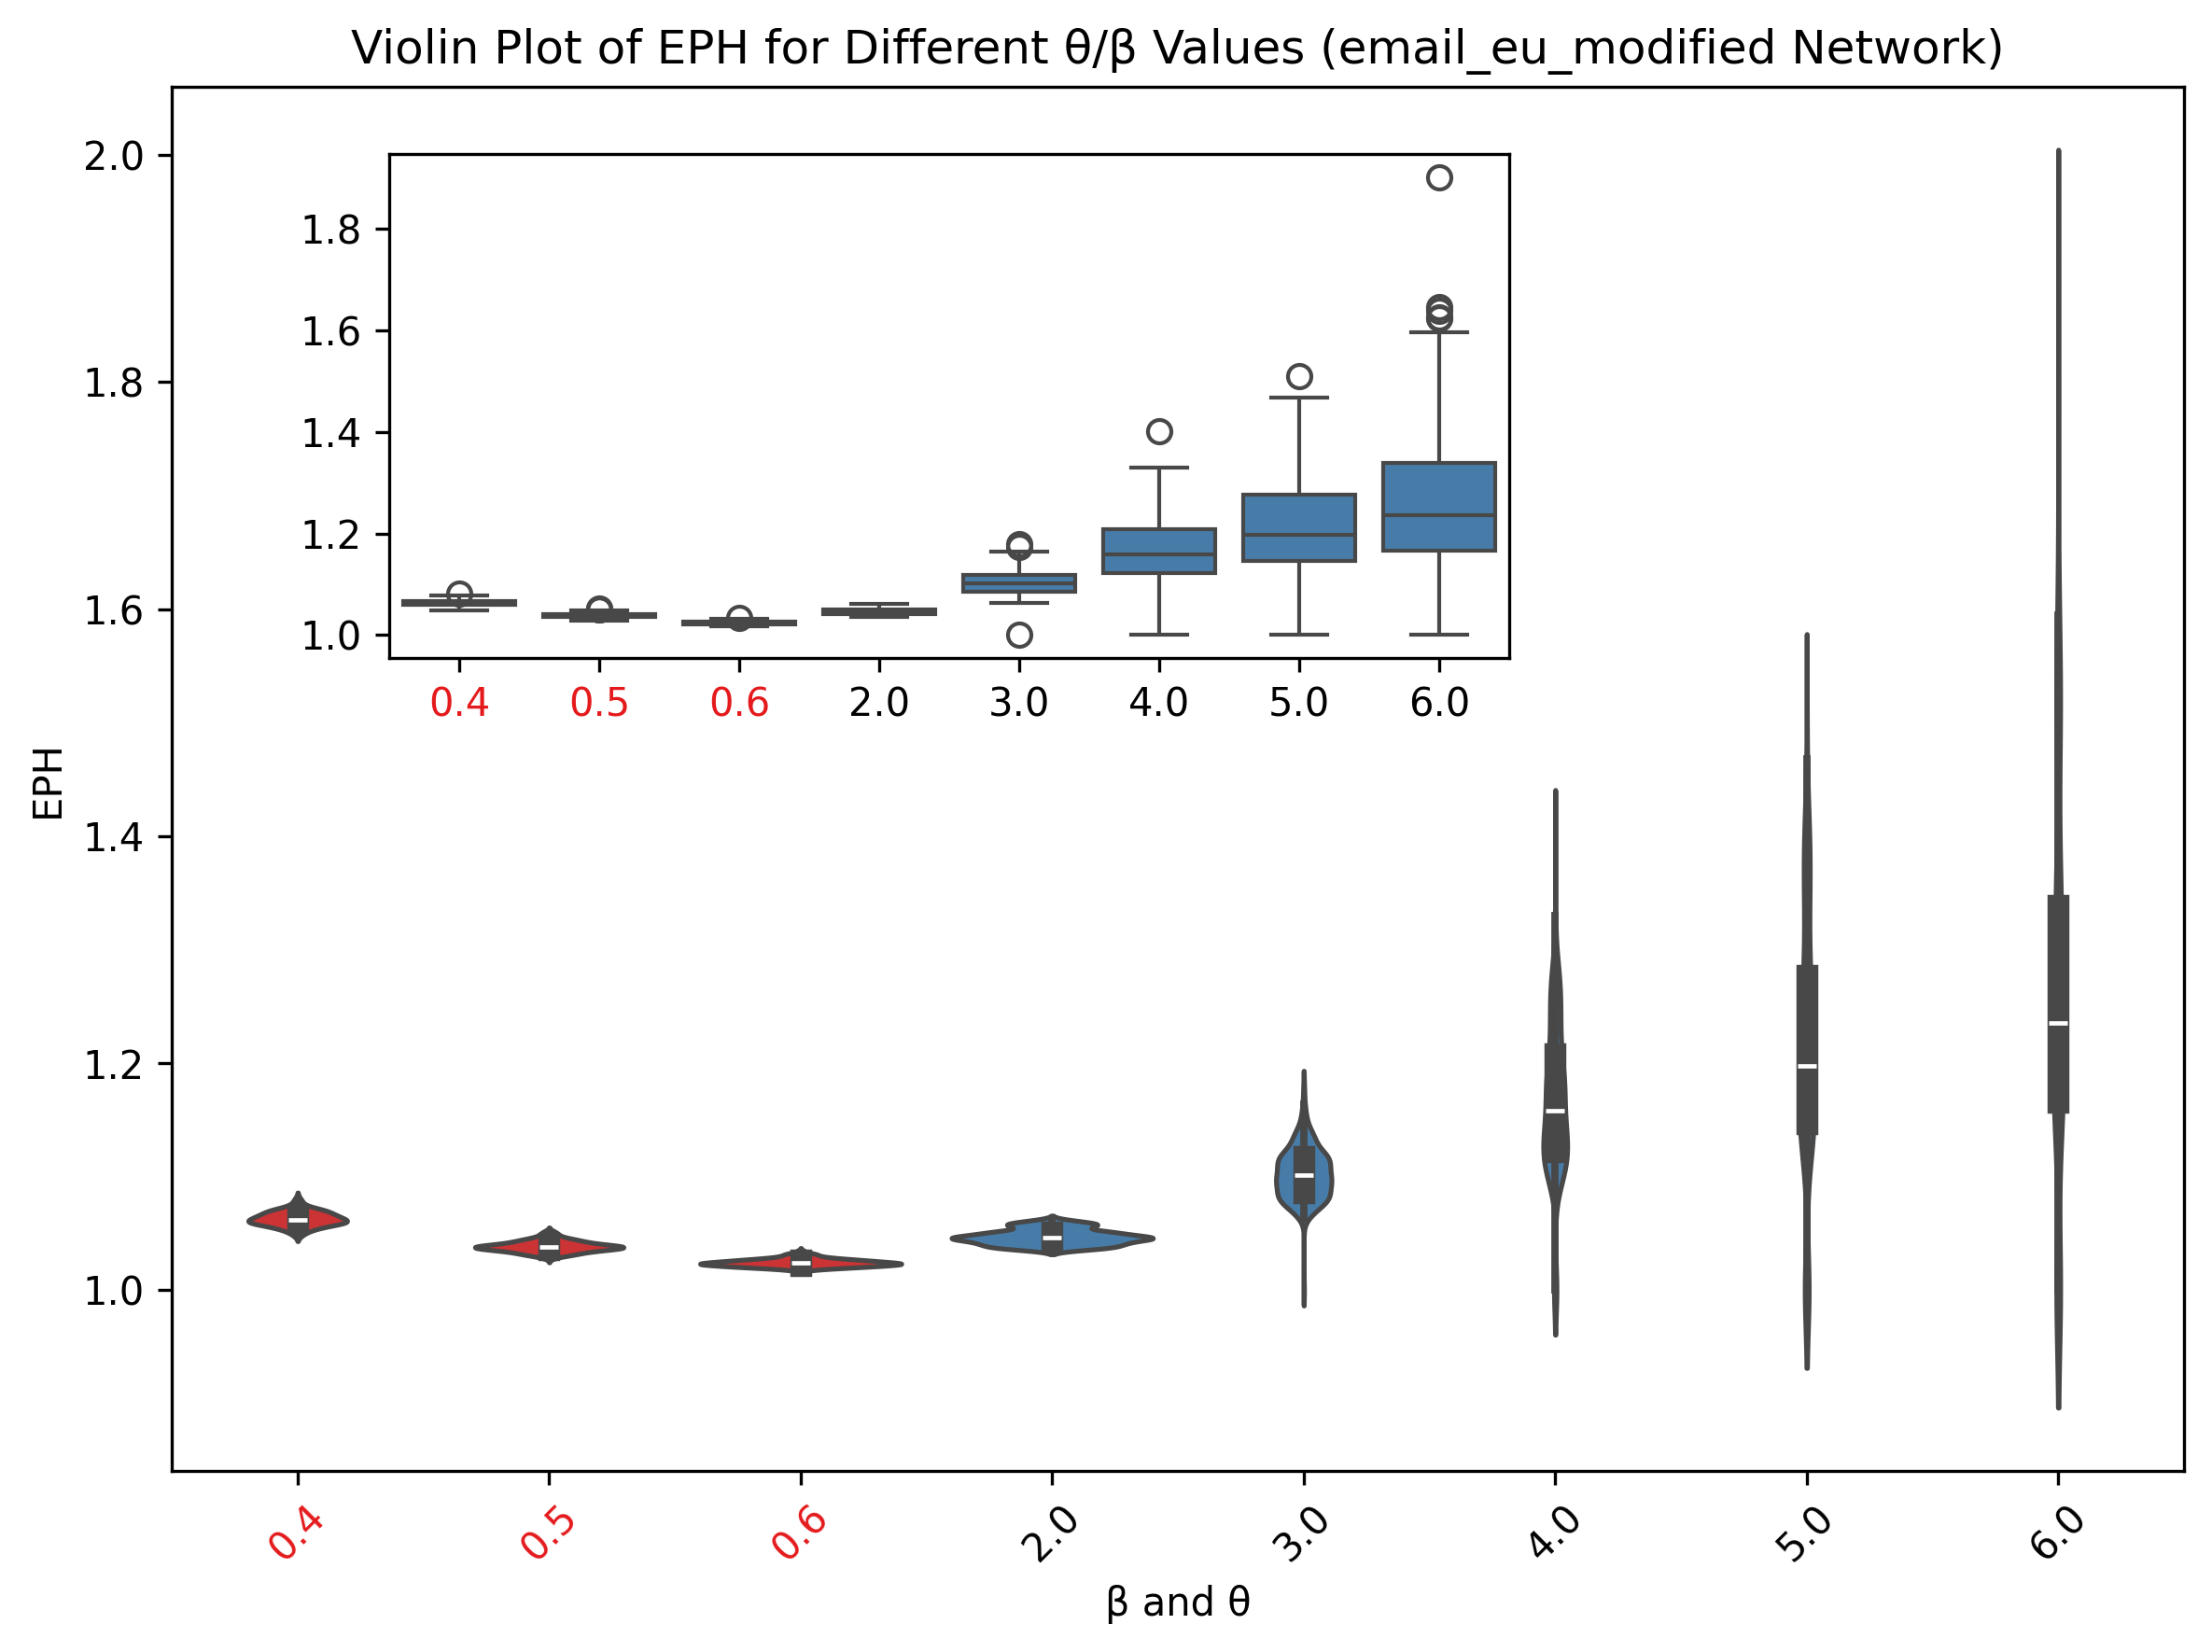

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/162729160.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


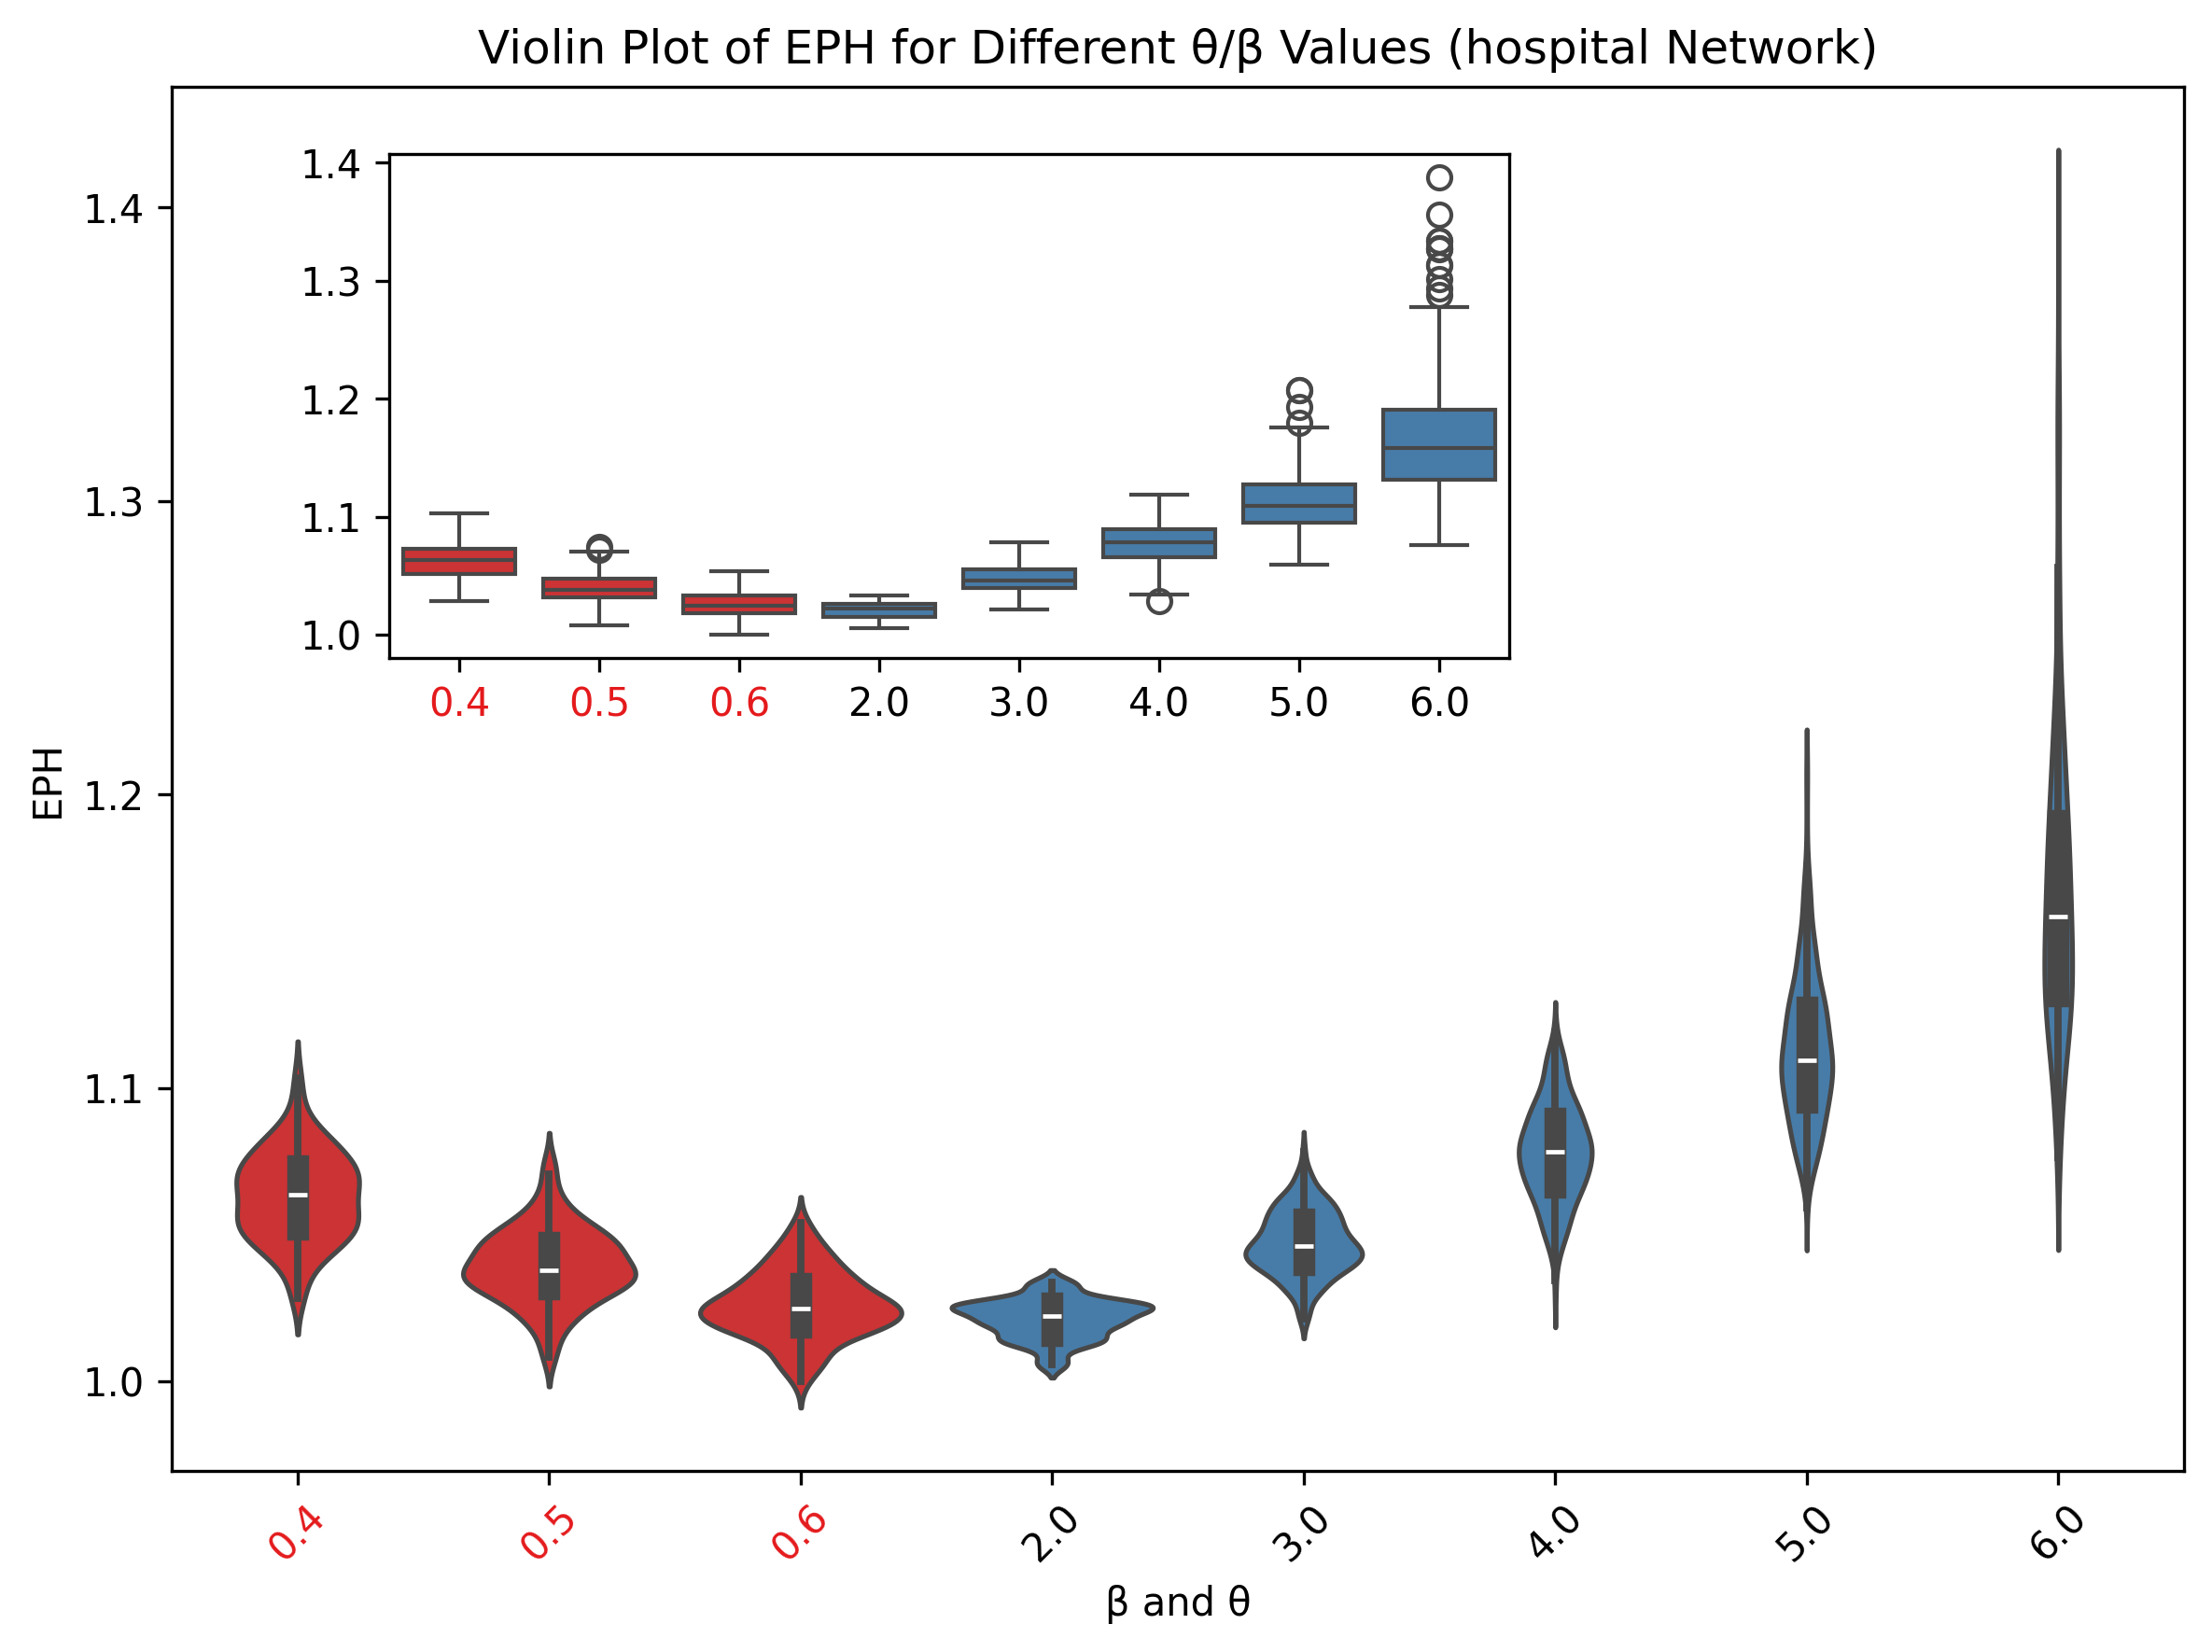

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/162729160.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


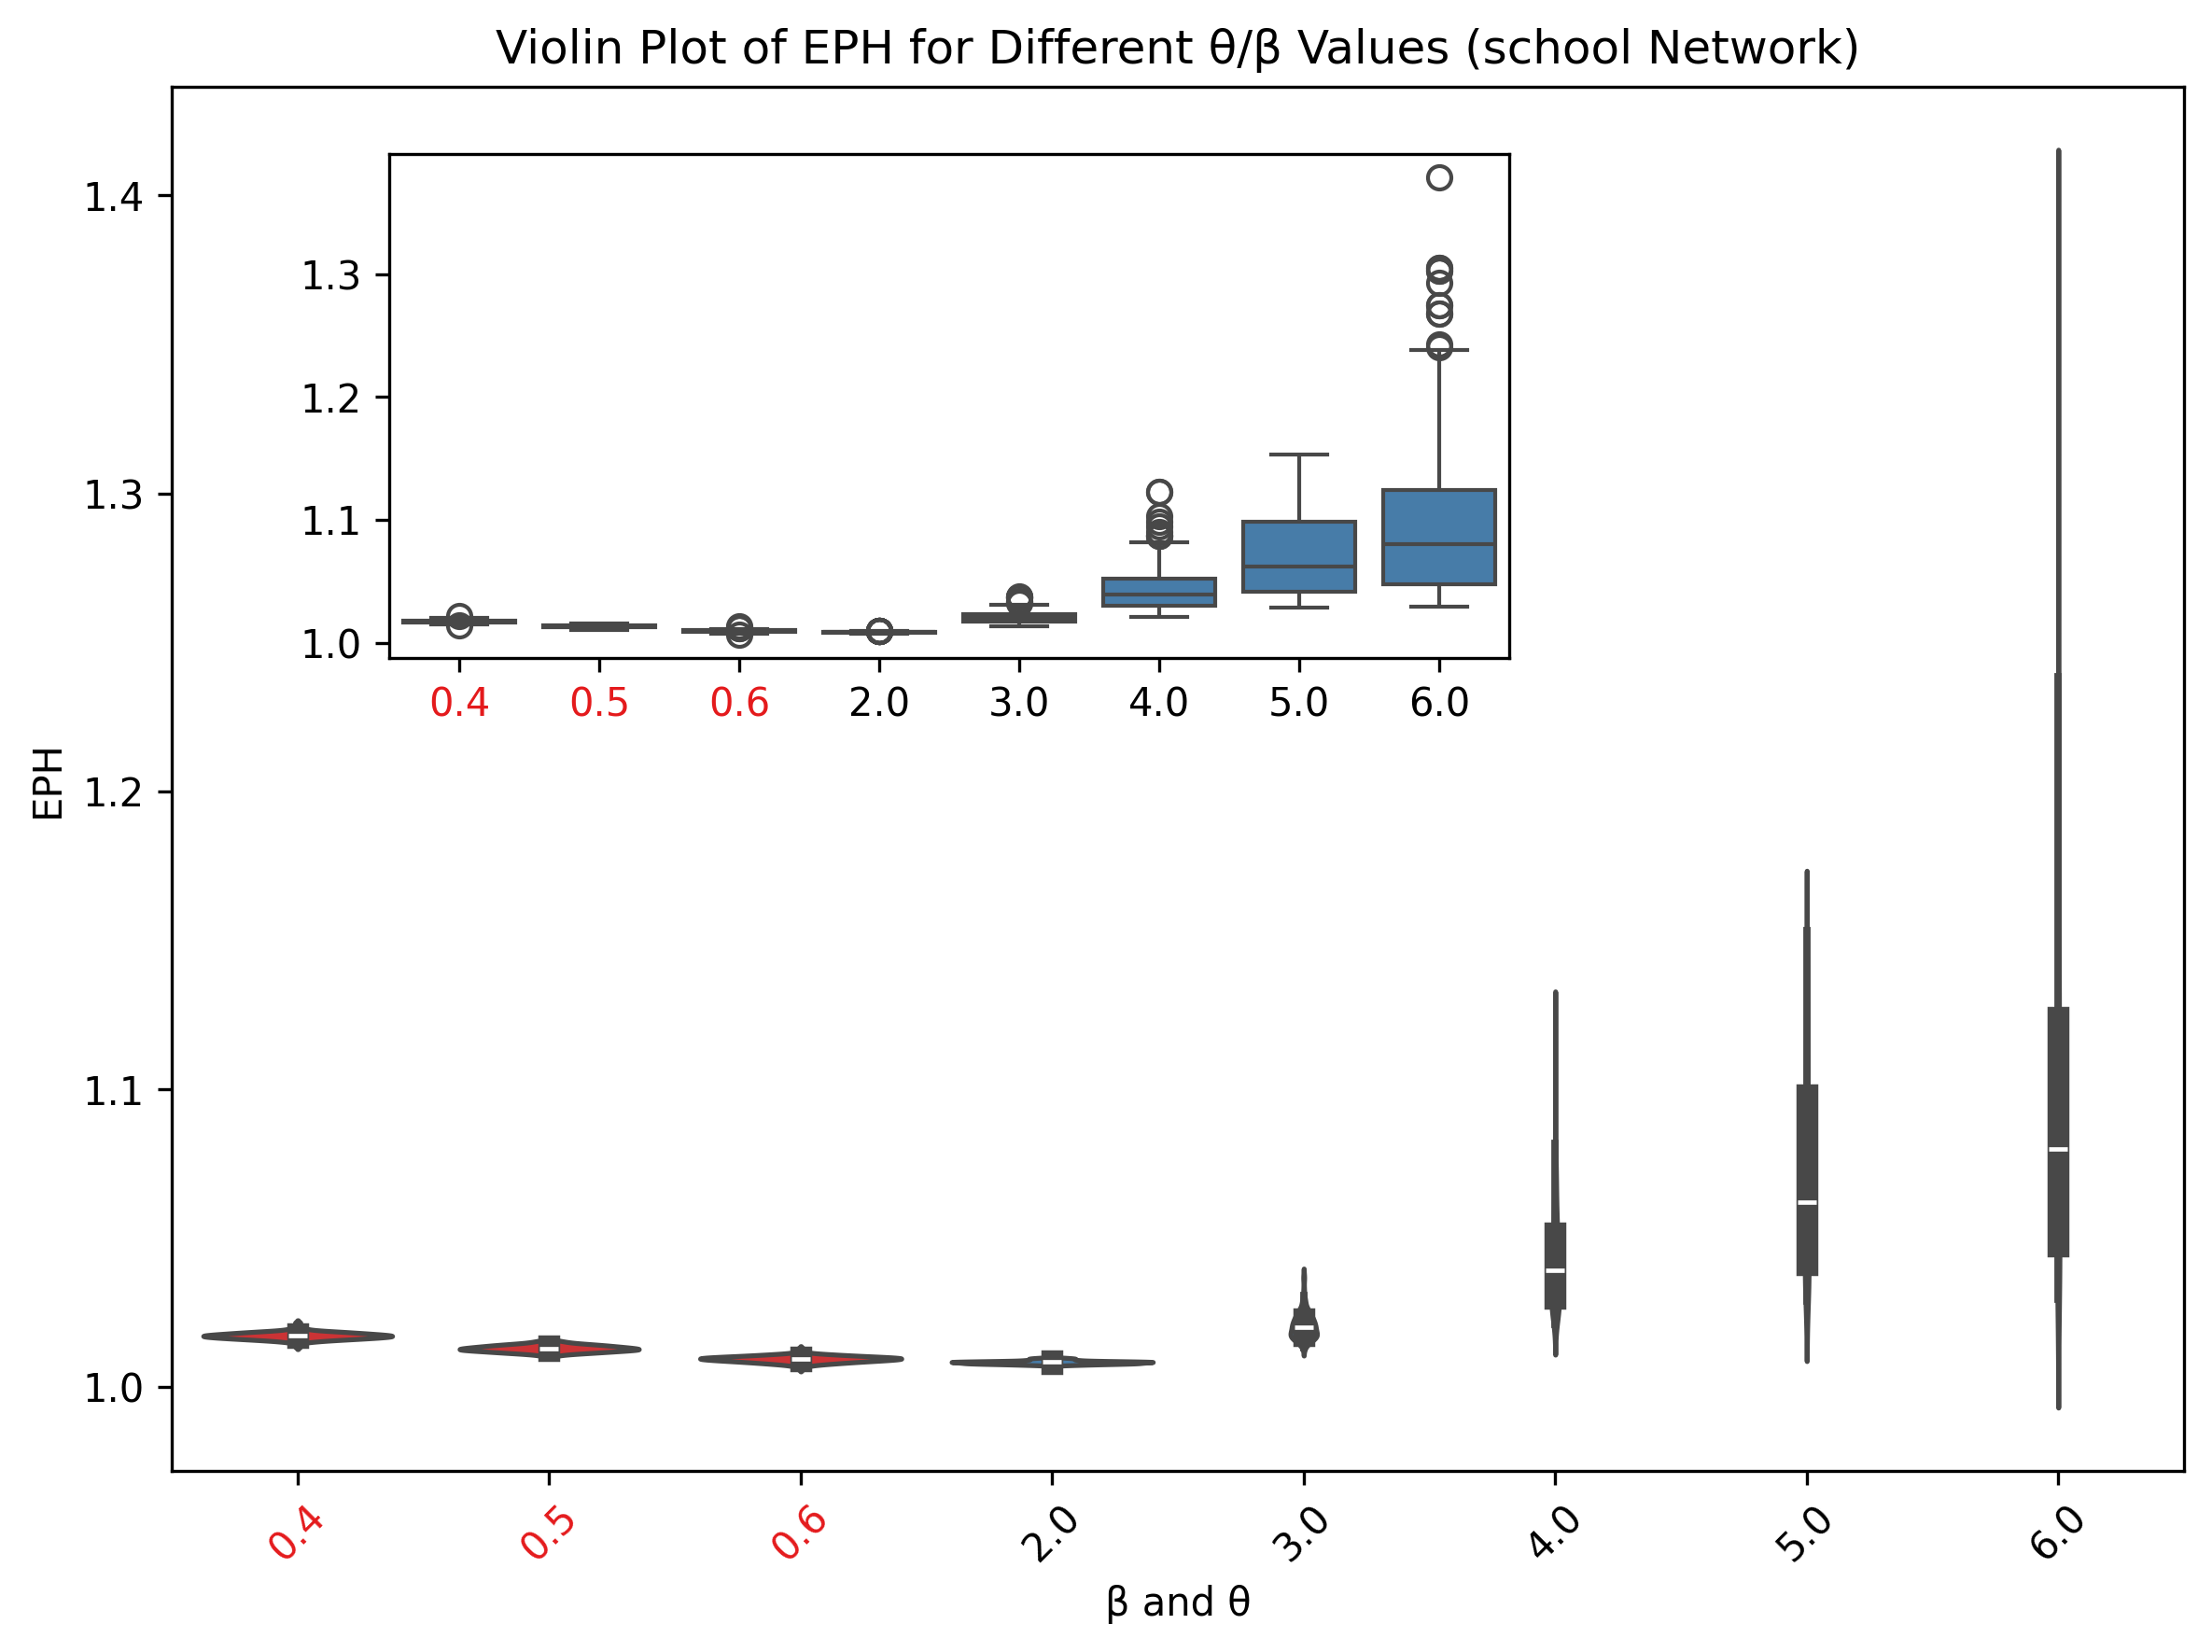

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_1341/162729160.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


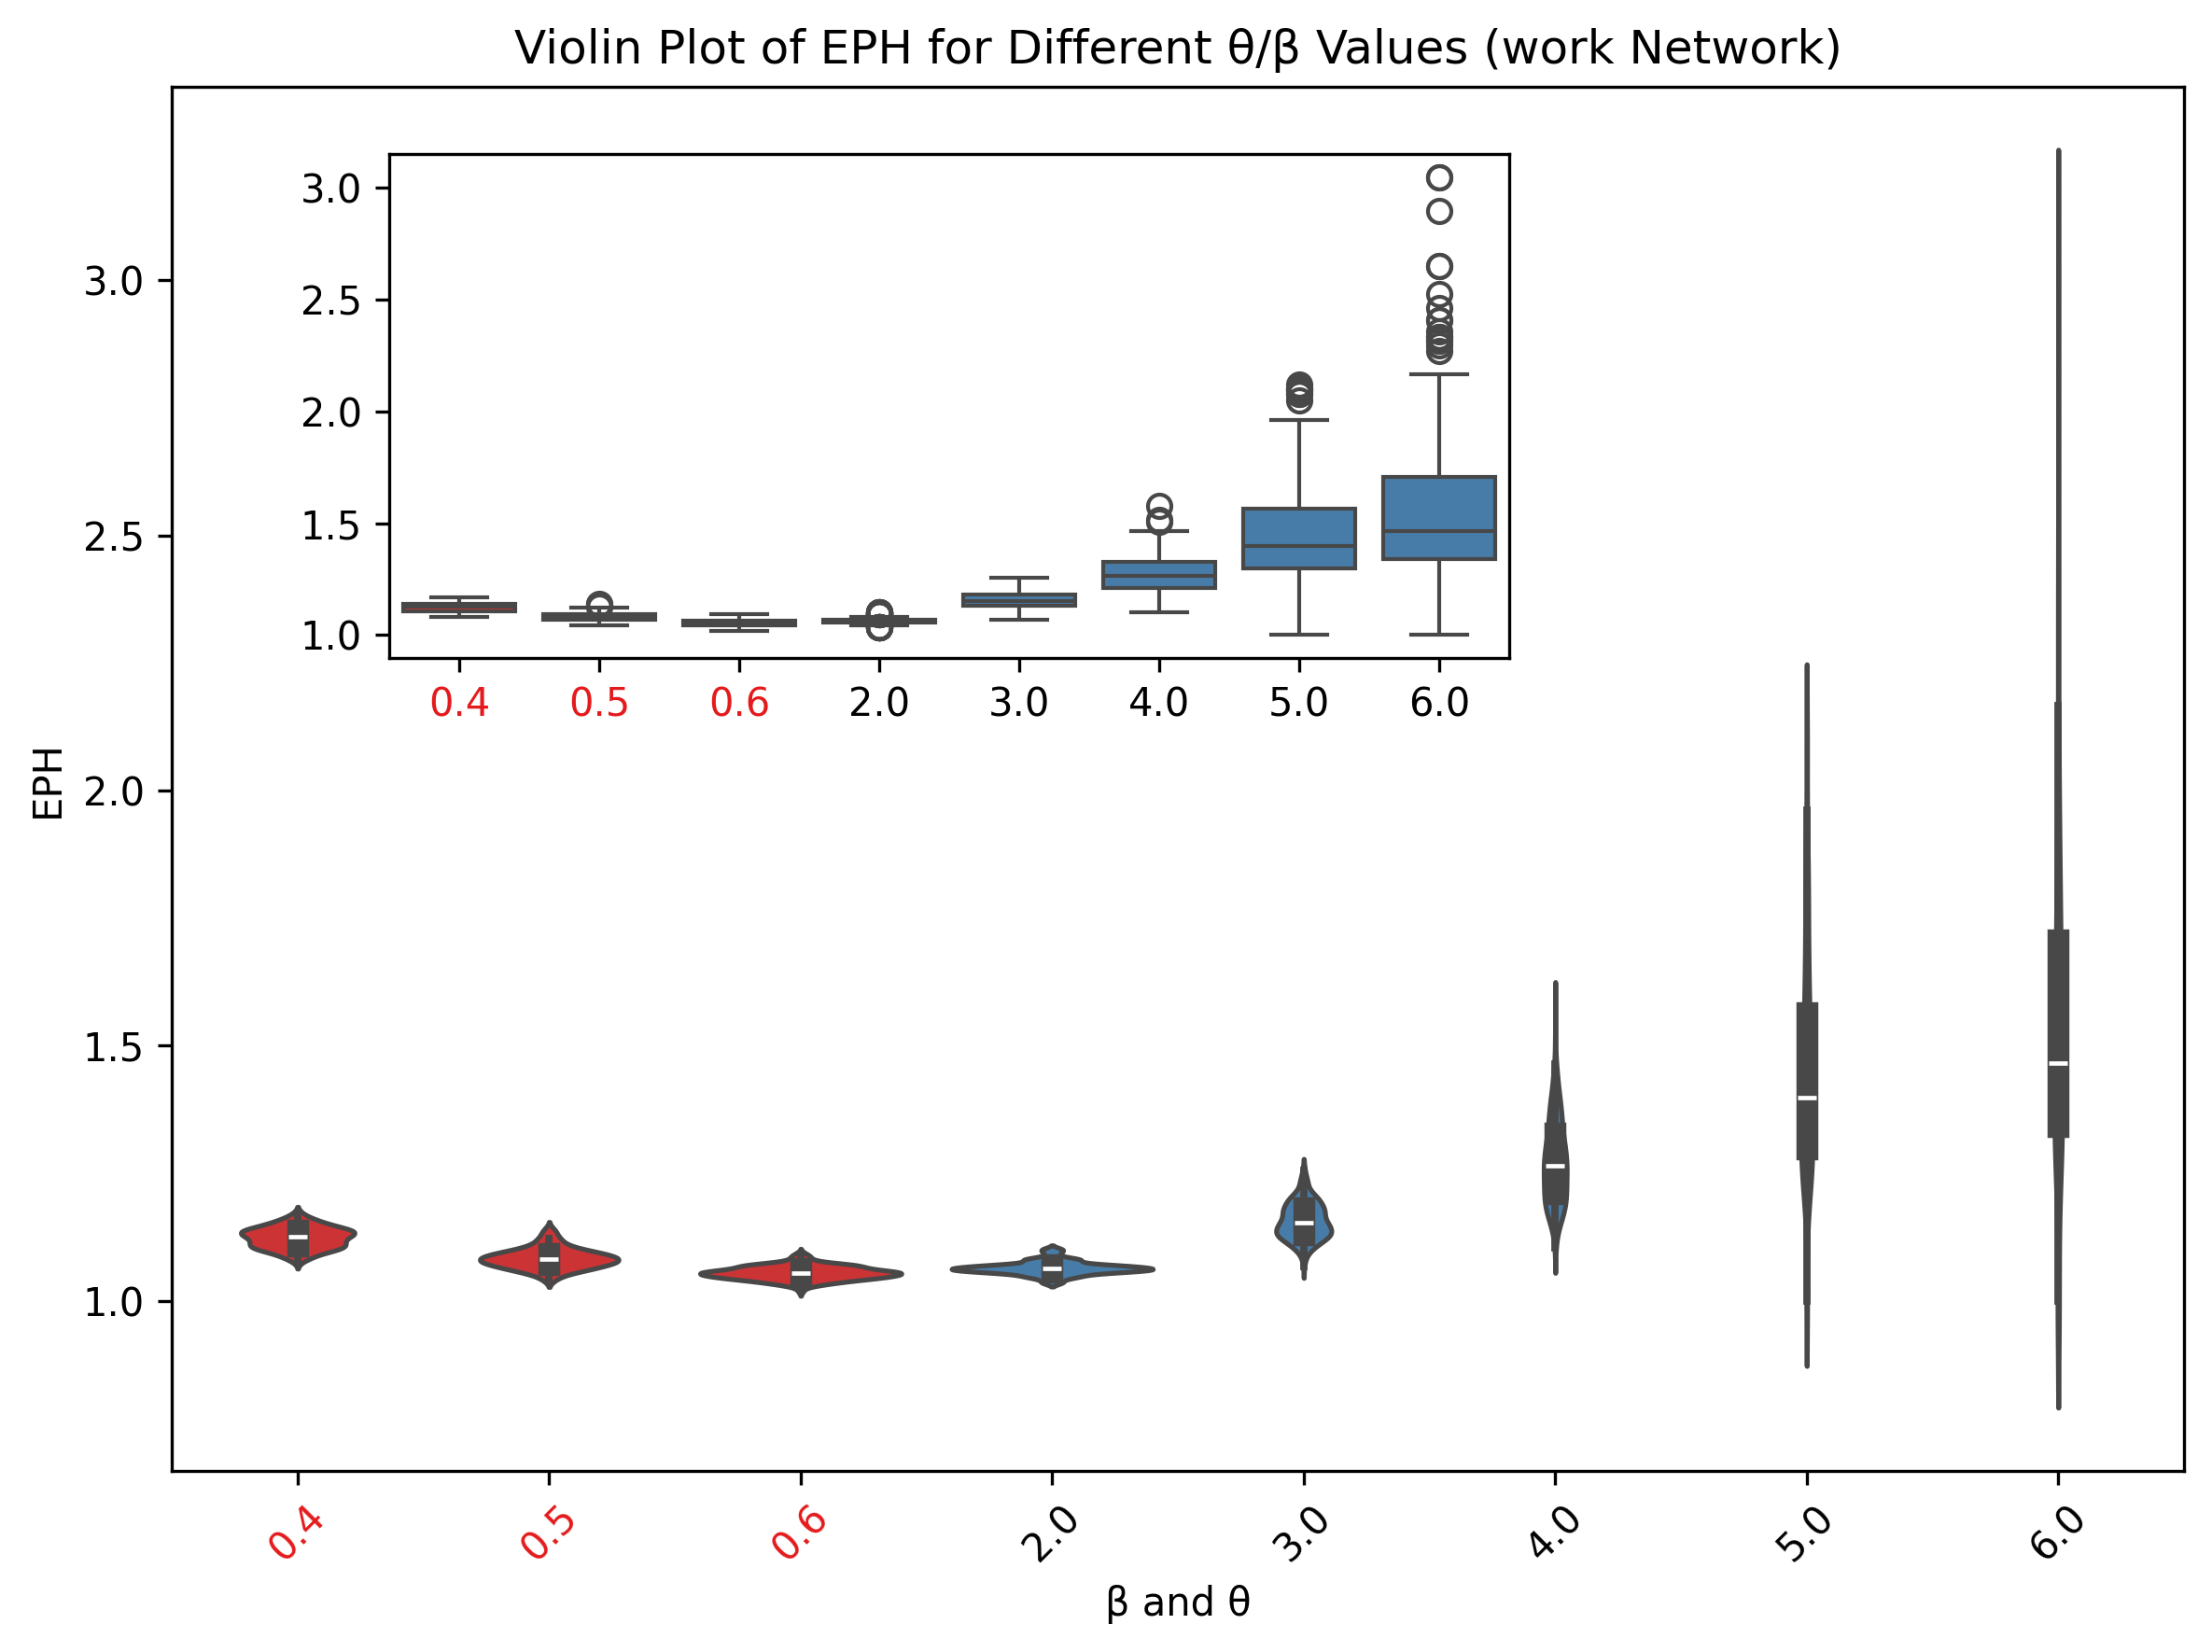

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_combined_violin_with_inset_boxplot(network_name):
    # Read data for complex network
    complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
    complex_data['network_type'] = 'Complex'
    complex_data['x_column'] = complex_data['theta']
    
    # Read data for simple network
    simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
    simple_data['network_type'] = 'Simple'
    simple_data['x_column'] = simple_data['betha']
    
    # Combine both
    combined_data = pd.concat([complex_data, simple_data], axis=0)
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    # Plot the main violin plot with specified colors for simple and complex contagion
    sns.violinplot(
        x='x_column', y='EPH', hue='network_type', data=combined_data, ax=ax, 
        palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
    )
    ax.set_xlabel('β and θ')
    ax.set_ylabel('EPH')
    ax.set_title(f'Violin Plot of EPH for Different θ/β Values ({network_name} Network)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend_.remove()  # Remove legend

    # Customize the x-axis labels with colors for the main violin plot
    for label in ax.get_xticklabels():
        if label.get_text() in complex_data['x_column'].astype(str).unique():
            label.set_color('#377eb8')
        elif label.get_text() in simple_data['x_column'].astype(str).unique():
            label.set_color('#e41a1c')
    
    # Create an inset axis for the box plot
    inset_ax = fig.add_axes([0.18, 0.60, 0.5, 0.3])  # Adjust position and size as needed
    sns.boxplot(
        x='x_column', y='EPH', hue='network_type', data=combined_data, ax=inset_ax,
        palette={'Complex': '#377eb8', 'Simple': '#e41a1c'}
    )
    inset_ax.set_xlabel('')
    inset_ax.set_ylabel('')
    inset_ax.set_title('')
    inset_ax.legend_.remove()  # Remove legend from the inset for clarity
    
    # Customize the x-axis labels with colors for the inset box plot
    for label in inset_ax.get_xticklabels():
        if label.get_text() in complex_data['x_column'].astype(str).unique():
            label.set_color('#377eb8')
        elif label.get_text() in simple_data['x_column'].astype(str).unique():
            label.set_color('#e41a1c')
    
    # Adjust layout and save the plot
    plt.tight_layout()
    base_path = "../results/unweighted_plots/violin_with_inset_boxplot_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    plot_filename = f"{base_path}/violin_with_inset_boxplot_{network_name}.svg"
    plt.savefig(plot_filename, format='svg', dpi=300, bbox_inches='tight')
    
    plt.show()

# Run the analysis for a set of networks
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']

# Create violin plots with an inset box plot for each network
for network_name in network_list:
    plot_combined_violin_with_inset_boxplot(network_name)


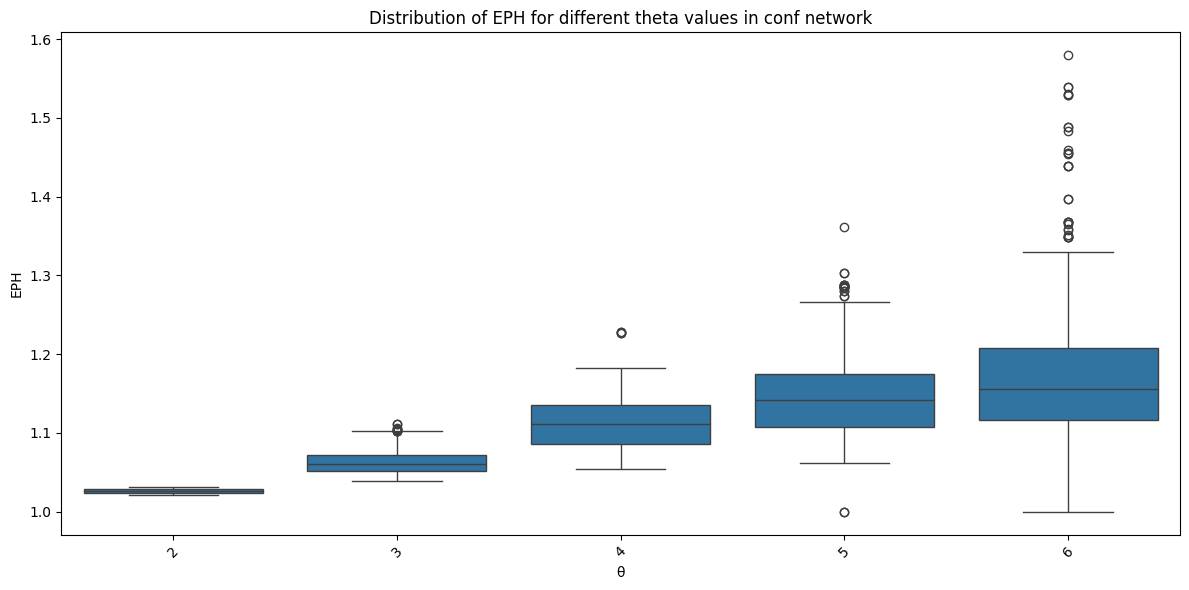

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_theta_eph_distribution(network_name, network_type='complex'):
    # Read data
    if network_type == 'complex':
        data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        x_column = 'theta'
    else:
        data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        x_column = 'betha'
    
    # Set up the figure
    plt.figure(figsize=(12, 6))
    
    # Plot EPH distribution for different values of theta or beta
    sns.boxplot(x=x_column, y='EPH', data=data)
    plt.xlabel('θ' if network_type == 'complex' else 'β')
    plt.ylabel('EPH')
    plt.title(f'Distribution of EPH for different {x_column} values in {network_name} network')
    
    # Adjust layout
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Create base path
    base_path = "../results/unweighted_plots/theta_eph_distribution_analysis"
    
    # Ensure directory exists
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot as SVG
    plot_filename = f"{base_path}/eph_distribution_{network_type}_{network_name}.svg"
    plt.savefig(plot_filename, format='svg', dpi=300, bbox_inches='tight')
    
    plt.show()

# Example network to analyze
network_name = 'conf'  # Replace with the desired network name

# Analyze a specific network for EPH distribution across different theta values
plot_theta_eph_distribution(network_name, 'complex')


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_993/1659683865.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp = ax_complex.boxplot([group['EPH'].values for name, group in complex_binned.groupby('bin')],


ValueError: List of boxplot statistics and `positions` values must have same the length

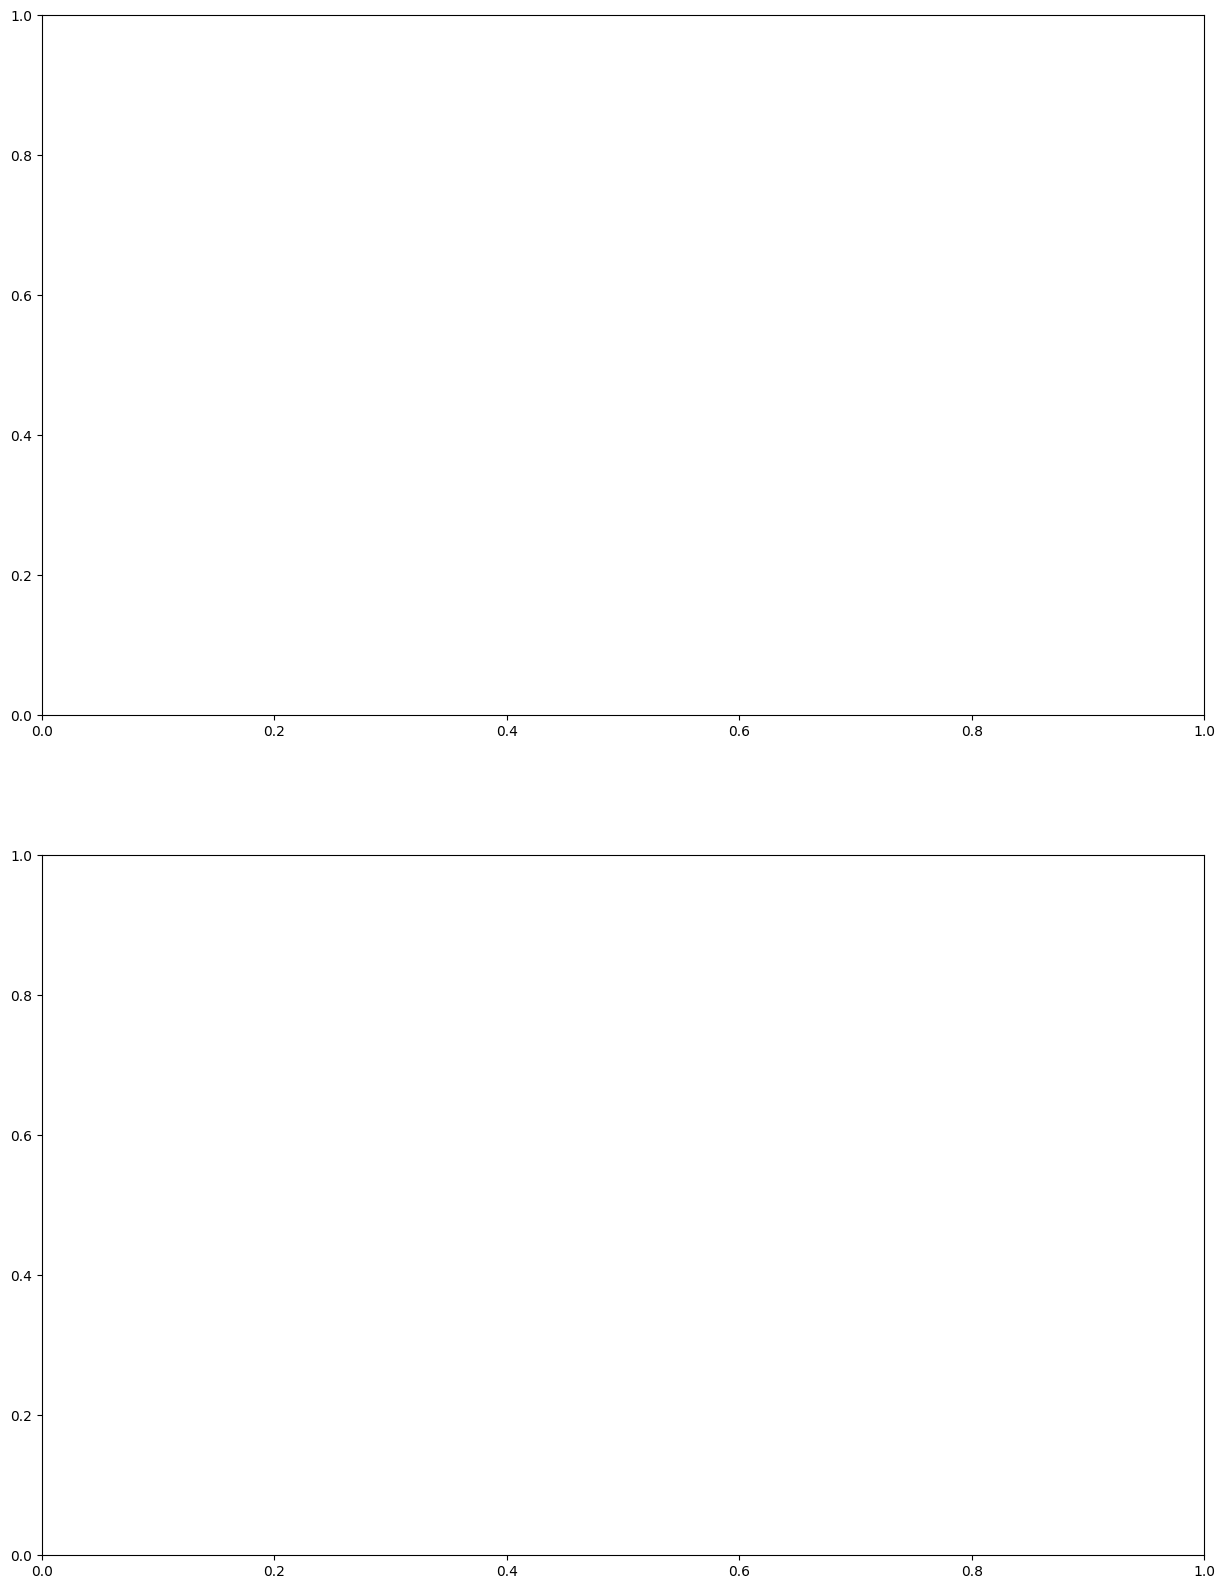

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

def ensure_dir(file_path):
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def create_binned_data(data, param_col, n_bins=8):
    """Create binned data and assign bin labels"""
    data = data.copy()
    bins = np.linspace(data[param_col].min(), data[param_col].max(), n_bins + 1)
    labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]
    data['bin'] = pd.cut(data[param_col], bins=bins, labels=labels)
    return data

def analyze_networks(network_list):
    # Create figure with two rows of plots
    fig, axes = plt.subplots(2, 1, figsize=(15, 20))
    
    # Custom colors for each network
    network_colors = {
        'conf': '#1f77b4',
        'email_eu_modified': '#2ca02c',
        'hospital': '#ff7f0e',
        'school': '#d62728',
        'work': '#9467bd'
    }
    
    # Store statistics
    stats_dict = {}
    
    # Plot for complex networks (theta)
    ax_complex = axes[0]
    position = 0
    box_positions = {}
    
    for network_name in network_list:
        # Read complex data
        complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        
        # Create binned data
        complex_binned = create_binned_data(complex_data, 'theta')
        
        # Calculate statistics
        stats_dict[f'{network_name}_complex'] = {
            'mean': complex_data['EPH'].mean(),
            'std': complex_data['EPH'].std(),
            'iqr': stats.iqr(complex_data['EPH'])
        }
        
        # Create box plot
        bp = ax_complex.boxplot([group['EPH'].values for name, group in complex_binned.groupby('bin')],
                              positions=np.arange(len(complex_binned['bin'].unique())) + position,
                              widths=0.15,
                              patch_artist=True)
        
        # Style the box plot
        plt.setp(bp['boxes'], facecolor=network_colors[network_name], alpha=0.6)
        plt.setp(bp['medians'], color='yellow')
        plt.setp(bp['whiskers'], color=network_colors[network_name])
        plt.setp(bp['caps'], color=network_colors[network_name])
        plt.setp(bp['fliers'], marker='o', markerfacecolor=network_colors[network_name], 
                markersize=4, alpha=0.5)
        
        # Store positions for legend
        box_positions[network_name] = position + len(complex_binned['bin'].unique())/2
        position += len(complex_binned['bin'].unique()) + 2
    
    # Customize complex plot
    ax_complex.set_title('Complex Networks: EPH Distribution across θ Values', pad=20, fontsize=14)
    ax_complex.set_xlabel('θ Range', fontsize=12)
    ax_complex.set_ylabel('EPH', fontsize=12)
    ax_complex.grid(True, linestyle='--', alpha=0.3)
    
    # Add network labels at the center of each group
    for network, pos in box_positions.items():
        ax_complex.text(pos, ax_complex.get_ylim()[0], network, 
                       ha='center', va='top', fontsize=10, rotation=0)
    
    # Plot for simple networks (betha)
    ax_simple = axes[1]
    position = 0
    box_positions = {}
    
    for network_name in network_list:
        # Read simple data
        simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Create binned data
        simple_binned = create_binned_data(simple_data, 'betha')
        
        # Calculate statistics
        stats_dict[f'{network_name}_simple'] = {
            'mean': simple_data['EPH'].mean(),
            'std': simple_data['EPH'].std(),
            'iqr': stats.iqr(simple_data['EPH'])
        }
        
        # Create box plot
        bp = ax_simple.boxplot([group['EPH'].values for name, group in simple_binned.groupby('bin')],
                             positions=np.arange(len(simple_binned['bin'].unique())) + position,
                             widths=0.15,
                             patch_artist=True)
        
        # Style the box plot
        plt.setp(bp['boxes'], facecolor=network_colors[network_name], alpha=0.6)
        plt.setp(bp['medians'], color='yellow')
        plt.setp(bp['whiskers'], color=network_colors[network_name])
        plt.setp(bp['caps'], color=network_colors[network_name])
        plt.setp(bp['fliers'], marker='o', markerfacecolor=network_colors[network_name], 
                markersize=4, alpha=0.5)
        
        # Store positions for legend
        box_positions[network_name] = position + len(simple_binned['bin'].unique())/2
        position += len(simple_binned['bin'].unique()) + 2
    
    # Customize simple plot
    ax_simple.set_title('Simple Networks: EPH Distribution across β Values', pad=20, fontsize=14)
    ax_simple.set_xlabel('β Range', fontsize=12)
    ax_simple.set_ylabel('EPH', fontsize=12)
    ax_simple.grid(True, linestyle='--', alpha=0.3)
    
    # Add network labels at the center of each group
    for network, pos in box_positions.items():
        ax_simple.text(pos, ax_simple.get_ylim()[0], network, 
                      ha='center', va='top', fontsize=10, rotation=0)
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], color=color, label=network, linewidth=4)
                      for network, color in network_colors.items()]
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.5))
    
    # Adjust layout
    plt.tight_layout()
    
    # Save results
    base_path = "../results/unweighted_plots/regression_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot
    plt.savefig(f"{base_path}/separated_boxplots.svg", format='svg', dpi=300, bbox_inches='tight')
    
    # Save statistics
    stats_df = pd.DataFrame(stats_dict).T
    stats_df.to_csv(f"{base_path}/separated_stats.csv")
    
    return stats_df, fig

# Run the analysis
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']
stats_df, fig = analyze_networks(network_list)
plt.close(fig)

print("\nNetwork Statistics:")
print(stats_df)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os

def ensure_dir(file_path):
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_network_distributions(network_list):
    # Set up the plots: one row for complex, one for simple
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 20))
    
    # Color map for different networks
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    # Plot for Complex Networks (theta)
    for idx, network_name in enumerate(network_list):
        # Read data
        complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        
        # Calculate the density
        theta = complex_data['theta']
        eph = complex_data['EPH']
        
        # Sort data for line plot
        sorted_indices = np.argsort(theta)
        theta_sorted = theta.iloc[sorted_indices]
        eph_sorted = eph.iloc[sorted_indices]
        
        # Plot mean line
        ax1.plot(theta_sorted, eph_sorted, color=colors[idx], 
                label=f'{network_name} (σ²={np.var(eph):.2e})', 
                alpha=0.7, linewidth=2)
        
        # Add scatter with transparency
        ax1.scatter(theta, eph, color=colors[idx], alpha=0.1, s=20)
    
    ax1.set_xlabel('θ (Complex Networks)')
    ax1.set_ylabel('EPH')
    ax1.set_title('EPH Distribution for Complex Networks\nAcross Different θ Values')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot for Simple Networks (beta)
    for idx, network_name in enumerate(network_list):
        # Read data
        simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Calculate the density
        beta = simple_data['betha']  # Note: using 'betha' as specified
        eph = simple_data['EPH']
        
        # Sort data for line plot
        sorted_indices = np.argsort(beta)
        beta_sorted = beta.iloc[sorted_indices]
        eph_sorted = eph.iloc[sorted_indices]
        
        # Plot mean line
        ax2.plot(beta_sorted, eph_sorted, color=colors[idx], 
                label=f'{network_name} (σ²={np.var(eph):.2e})', 
                alpha=0.7, linewidth=2)
        
        # Add scatter with transparency
        ax2.scatter(beta, eph, color=colors[idx], alpha=0.1, s=20)
    
    ax2.set_xlabel('β (Simple Networks)')
    ax2.set_ylabel('EPH')
    ax2.set_title('EPH Distribution for Simple Networks\nAcross Different β Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save results
    base_path = "../results/unweighted_plots/regression_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot
    plt.savefig(f"{base_path}/distribution_comparison.svg", format='svg', dpi=300, bbox_inches='tight')
    
    return fig

# Run the analysis
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']
fig = plot_network_distributions(network_list)
plt.close(fig)

In [3]:
network_list = [
    'conf','email_eu_modified','hospital','school','work'
]

In [7]:
network_list = [
    'conf','email_eu_modified','hospital','school','work'
]

network_name = network_list[0]
complex_c = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
simple_c = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')

theta = complex_c['theta']
eph = complex_c['EPH']

In [8]:
simple_c

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,0,1,2,3,4,5,6,...,397,398,399,400,401,402,betha,seed,EPH,corr
0,0,0,0,1,2,2,2,1,1,2,...,2,2,2,2,1,2,0.4,0,1.041534,-0.499325
1,1,1,1,1,2,2,2,1,2,2,...,2,1,2,1,2,2,0.5,1,1.019725,-0.365408
2,2,2,2,1,1,1,1,1,2,1,...,2,2,2,2,1,2,0.4,2,1.036389,-0.441905
3,3,3,3,2,1,1,1,1,1,1,...,2,1,2,1,2,2,0.6,3,1.021041,-0.446531
4,4,4,4,1,1,2,1,1,1,1,...,2,1,1,1,2,2,0.6,4,1.020852,-0.401503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,95,95,95,1,1,1,2,1,2,2,...,2,2,1,2,2,2,0.6,95,1.017451,-0.336962
296,96,96,96,2,1,1,1,1,2,1,...,2,1,3,2,2,2,0.4,96,1.045426,-0.387438
297,97,97,97,2,1,2,1,1,1,1,...,1,2,2,2,2,2,0.6,97,1.020708,-0.375750
298,98,98,98,2,1,0,1,1,1,2,...,2,1,1,1,1,2,0.6,98,1.026701,-0.320178


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def plot_eph_distribution(network_list, network_type='complex'):
    # Set up the figure for all networks
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.ravel()
    
    # Loop through the networks to create box plots or distribution plots
    for idx, network_name in enumerate(network_list):
        # Read data
        if network_type == 'complex':
            data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        else:
            data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Plot EPH distribution
        sns.boxplot(data['EPH'], ax=axs[idx])
        axs[idx].set_xlabel('EPH')
        axs[idx].set_title(f'Network: {network_name}')
    
    # Remove extra subplot if any
    if len(network_list) < len(axs):
        for i in range(len(network_list), len(axs)):
            fig.delaxes(axs[i])
    
    # Adjust layout
    plt.tight_layout()
    
    # Create base path
    base_path = "../results/unweighted_plots/eph_distribution_analysis"
    
    # Ensure directory exists
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot as SVG
    plot_filename = f"{base_path}/eph_distribution_{network_type}_networks.svg"
    plt.savefig(plot_filename, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

# Run the analysis for both network types
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']

# Analyze complex networks (EPH distribution)
complex_fig = plot_eph_distribution(network_list, 'complex')
plt.close(complex_fig)  # Close the figure to free memory

# Analyze simple networks (EPH distribution)
simple_fig = plot_eph_distribution(network_list, 'simple')
plt.close(simple_fig)  # Close the figure to free memory

print("Plots for EPH distributions have been saved.")


Plots for EPH distributions have been saved.


In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib.backends.backend_svg import FigureCanvasSVG
import os

def ensure_dir(file_path):
    """Create directory if it doesn't exist"""
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def perform_regression_analysis(network_list, network_type='complex'):
    # Set up the figure for all networks
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.ravel()
    
    # Dictionary to store regression results
    results = {}
    
    x_column = 'theta' if network_type == 'complex' else 'betha'
    
    for idx, network_name in enumerate(network_list):
        # Read data
        if network_type == 'complex':
            data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        else:
            data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Prepare data for regression
        X = data[x_column].values.reshape(-1, 1)
        y = data['EPH'].values
        
        # Perform linear regression
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        
        # Calculate R-squared
        r2 = r2_score(y, y_pred)
        
        # Store results
        results[network_name] = {
            'slope': model.coef_[0],
            'intercept': model.intercept_,
            'r2': r2
        }
        
        # Plot
        axs[idx].scatter(X, y, alpha=0.5, label='Data points')
        axs[idx].plot(X, y_pred, color='red', label=f'Regression line\nR² = {r2:.3f}')
        axs[idx].set_xlabel('θ' if network_type == 'complex' else 'β')
        axs[idx].set_ylabel('EPH')
        axs[idx].set_title(f'Network: {network_name}')
        axs[idx].legend()
        
        # Add regression equation text
        equation = f'y = {model.coef_[0]:.3f}x + {model.intercept_:.3f}'
        axs[idx].text(0.05, 0.95, equation, transform=axs[idx].transAxes, 
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Remove extra subplot if any
    if len(network_list) < len(axs):
        for i in range(len(network_list), len(axs)):
            fig.delaxes(axs[i])
    
    # Adjust layout
    plt.tight_layout()
    
    # Create base path
    base_path = "../results/unweighted_plots/regression_analysis"
    
    # Ensure directory exists
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot as SVG
    plot_filename = f"{base_path}/regression_{network_type}_networks.svg"
    plt.savefig(plot_filename, format='svg', dpi=300, bbox_inches='tight')
    
    # Save regression results to CSV
    results_filename = f"{base_path}/regression_results_{network_type}_networks.csv"
    results_df = pd.DataFrame(results).T
    results_df.to_csv(results_filename)
    
    return results_df, fig

# Run the analysis for both network types
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']

# Analyze complex networks (theta vs EPH)
complex_results, complex_fig = perform_regression_analysis(network_list, 'complex')
plt.close(complex_fig)  # Close the figure to free memory

# Analyze simple networks (beta vs EPH)
simple_results, simple_fig = perform_regression_analysis(network_list, 'simple')
plt.close(simple_fig)  # Close the figure to free memory

print("\nComplex Network Regression Results:")
print(complex_results)
print("\nSimple Network Regression Results:")
print(simple_results)


Complex Network Regression Results:
                      slope  intercept        r2
conf               0.038507   0.951431  0.488232
email_eu_modified  0.053712   0.943389  0.388788
hospital           0.035565   0.942308  0.753527
school             0.022147   0.958485  0.482428
work               0.127116   0.789762  0.469000

Simple Network Regression Results:
                      slope  intercept        r2
conf              -0.096250   1.075125  0.786252
email_eu_modified -0.192581   1.138166  0.891776
hospital          -0.182466   1.134046  0.554252
school            -0.038871   1.032735  0.887168
work              -0.341020   1.257533  0.695370


In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib.backends.backend_svg import FigureCanvasSVG
import os

def ensure_dir(file_path):
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def calculate_binned_variance(x, y, n_bins=10):
    """Calculate variance of y in bins of x"""
    bins = np.linspace(min(x), max(x), n_bins+1)
    digitized = np.digitize(x, bins)
    variances = [np.var(y[digitized == i]) for i in range(1, len(bins))]
    bin_centers = (bins[:-1] + bins[1:]) / 2
    return bin_centers, variances

def perform_comparative_analysis(network_list):
    fig, axs = plt.subplots(2, 3, figsize=(20, 12))
    axs = axs.ravel()
    
    # Create summary statistics dictionary
    summary_stats = {}
    
    for idx, network_name in enumerate(network_list):
        # Read data
        complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Calculate overall variance for each type
        complex_var = np.var(complex_data['EPH'])
        simple_var = np.var(simple_data['EPH'])
        
        # Store statistics
        summary_stats[network_name] = {
            'complex_variance': complex_var,
            'simple_variance': simple_var,
            'variance_ratio': simple_var/complex_var
        }
        
        # Main scatter plot
        ax1 = axs[idx]
        
        # Plot complex data
        complex_scatter = ax1.scatter(complex_data['theta'], complex_data['EPH'], 
                                    alpha=0.5, label='Complex (θ)', color='blue')
        simple_scatter = ax1.scatter(simple_data['betha'], simple_data['EPH'], 
                                   alpha=0.5, label='Simple (β)', color='red')
        
        # Calculate and plot binned variance
        bin_centers_complex, var_complex = calculate_binned_variance(complex_data['theta'], complex_data['EPH'])
        bin_centers_simple, var_simple = calculate_binned_variance(simple_data['betha'], simple_data['EPH'])
        
        # Create twin axis for variance
        ax2 = ax1.twinx()
        ax2.plot(bin_centers_complex, var_complex, '--', color='blue', alpha=0.7, 
                label='Complex variance')
        ax2.plot(bin_centers_simple, var_simple, '--', color='red', alpha=0.7, 
                label='Simple variance')
        
        # Set labels and title
        ax1.set_xlabel('Parameter Value (θ for Complex, β for Simple)')
        ax1.set_ylabel('EPH')
        ax2.set_ylabel('Local Variance')
        
        # Title with variance information
        title = (f'Network: {network_name}\n'
                f'Overall Variance Ratio (Simple/Complex): {simple_var/complex_var:.2f}\n'
                f'Simple σ²: {simple_var:.2e}, Complex σ²: {complex_var:.2e}')
        ax1.set_title(title)
        
        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
        # Set y-axis colors
        ax1.yaxis.label.set_color('black')
        ax2.yaxis.label.set_color('green')
        ax2.tick_params(axis='y', colors='green')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the plot
    base_path = "../results/unweighted_plots/regression_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot and statistics
    plt.savefig(f"{base_path}/variance_comparison.svg", format='svg', dpi=300, bbox_inches='tight')
    
    # Save summary statistics
    summary_df = pd.DataFrame(summary_stats).T
    summary_df.to_csv(f"{base_path}/variance_comparison_stats.csv")
    
    return summary_df, fig

# Run the analysis
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']
summary_stats, fig = perform_comparative_analysis(network_list)
plt.close(fig)

print("\nVariance Comparison Summary:")
print(summary_stats)


Variance Comparison Summary:
                   complex_variance  simple_variance  variance_ratio
conf                       0.005592         0.000075        0.013414
email_eu_modified          0.014420         0.000275        0.019076
hospital                   0.003091         0.000382        0.123737
school                     0.001872         0.000011        0.005792
work                       0.063438         0.001065        0.016784


OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

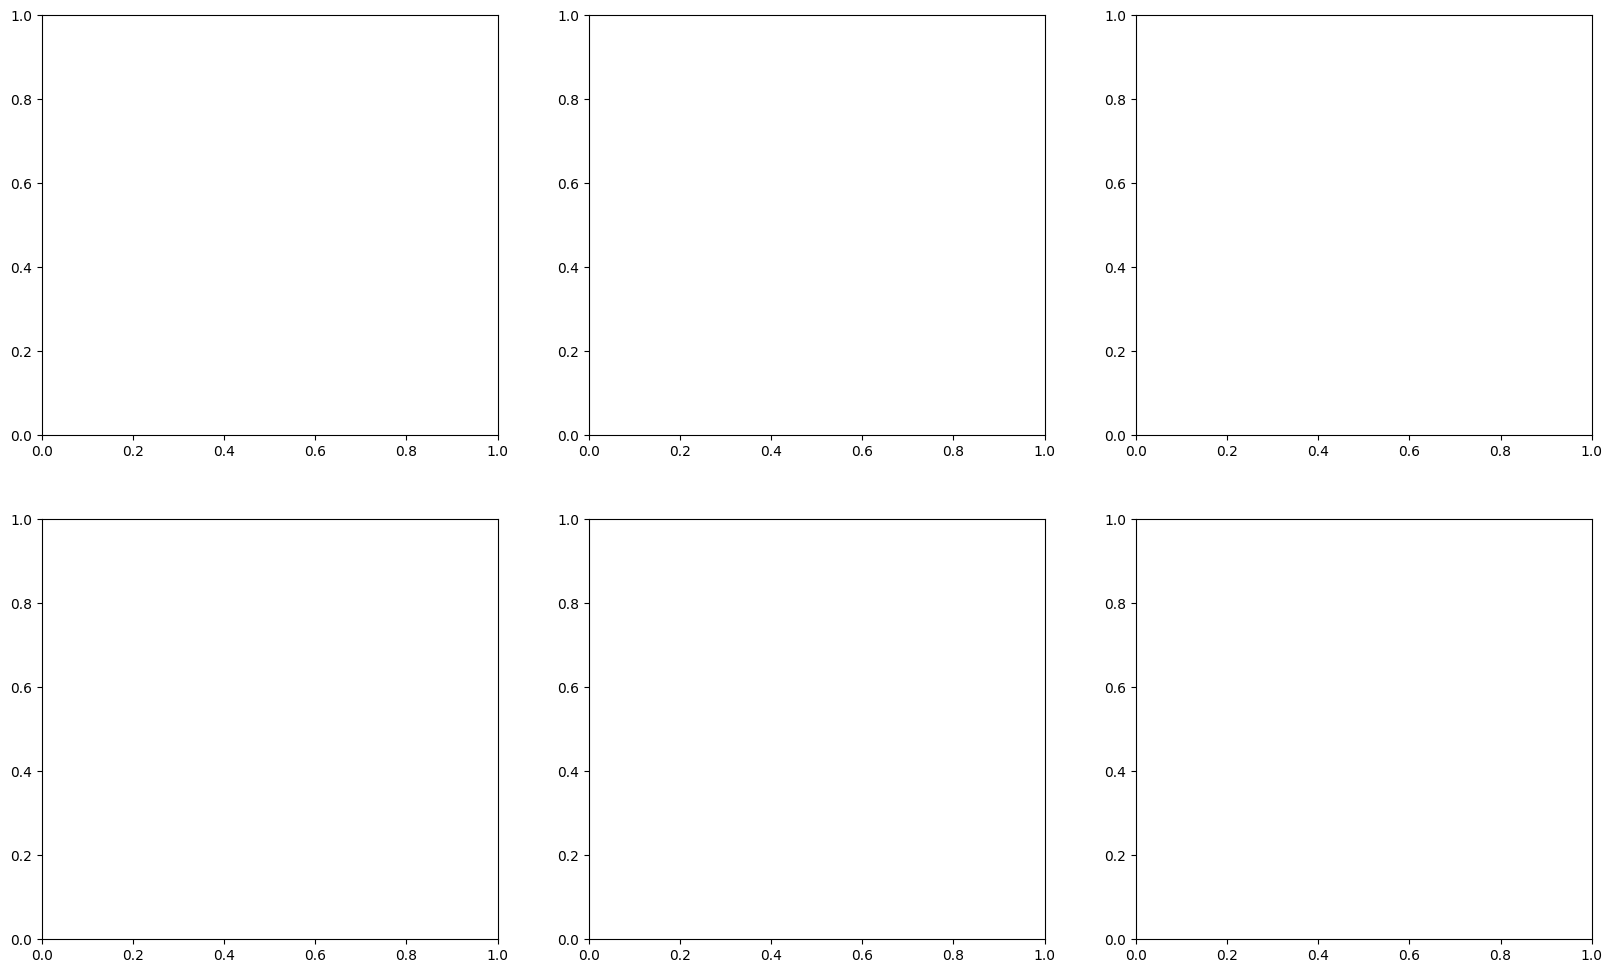

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

def ensure_dir(file_path):
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)

def create_binned_data(data, param_col, n_bins=5):
    """Create binned data and assign bin labels"""
    data = data.copy()
    bins = np.linspace(data[param_col].min(), data[param_col].max(), n_bins + 1)
    labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]
    data['bin'] = pd.cut(data[param_col], bins=bins, labels=labels)
    return data

def analyze_variability(network_list):
    fig, axs = plt.subplots(2, 3, figsize=(20, 12))
    axs = axs.ravel()
    
    # Store statistics
    stats_dict = {}
    
    for idx, network_name in enumerate(network_list):
        # Read data
        complex_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_complex_{network_name}_EPH.csv')
        simple_data = pd.read_csv(f'../results/unweighted/given_q_n=300/unweighted_simple_{network_name}_EPH.csv')
        
        # Create binned data
        complex_binned = create_binned_data(complex_data, 'theta')
        simple_binned = create_binned_data(simple_data, 'betha')
        
        # Calculate statistics
        complex_std = complex_data['EPH'].std()
        simple_std = simple_data['EPH'].std()
        complex_iqr = stats.iqr(complex_data['EPH'])
        simple_iqr = stats.iqr(simple_data['EPH'])
        
        stats_dict[network_name] = {
            'complex_std': complex_std,
            'simple_std': simple_std,
            'std_ratio': simple_std/complex_std,
            'complex_iqr': complex_iqr,
            'simple_iqr': simple_iqr,
            'iqr_ratio': simple_iqr/complex_iqr
        }
        
        ax = axs[idx]
        
        # Get binned data for plotting
        complex_groups = [group['EPH'].values for name, group in complex_binned.groupby('bin')]
        simple_groups = [group['EPH'].values for name, group in simple_binned.groupby('bin')]
        
        # Positions for box plots
        positions_complex = np.arange(len(complex_binned['bin'].unique())) * 2.5
        positions_simple = positions_complex + 0.8
        
        # Create box plots
        bp1 = ax.boxplot(complex_groups, positions=positions_complex, widths=0.6,
                        patch_artist=True)
        bp2 = ax.boxplot(simple_groups, positions=positions_simple, widths=0.6,
                        patch_artist=True)
        
        # Customize box plots
        def style_boxplot(bp, color, alpha=0.3):
            for element in ['boxes', 'whiskers', 'fliers', 'caps']:
                plt.setp(bp[element], color=color)
            plt.setp(bp['medians'], color='yellow')
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(alpha)
        
        style_boxplot(bp1, 'blue')
        style_boxplot(bp2, 'red')
        
        # Customize plot
        ax.set_xticks(positions_complex + 0.4)
        ax.set_xticklabels(complex_binned['bin'].unique(), rotation=45)
        
        # Add grid for better readability
        ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
        ax.set_axisbelow(True)
        
        # Add title and labels
        ax.set_title(f'Network: {network_name}\nVariability Ratio (Simple/Complex)\n'
                    f'Std: {stats_dict[network_name]["std_ratio"]:.2f}, '
                    f'IQR: {stats_dict[network_name]["iqr_ratio"]:.2f}')
        ax.set_xlabel('Parameter Range (θ for Complex, β for Simple)')
        ax.set_ylabel('EPH Distribution')
        
        # Add legend
        ax.plot([], [], color='blue', label='Complex (θ)', alpha=0.5)
        ax.plot([], [], color='red', label='Simple (β)', alpha=0.5)
        ax.legend()
    
    plt.tight_layout()
    
    # Save results
    base_path = "../results/unweighted_plots/regression_analysis"
    ensure_dir(f"{base_path}/temp.txt")
    
    # Save plot
    plt.savefig(f"{base_path}/variability_boxplot.svg", format='svg', dpi=300, bbox_inches='tight')
    
    # Save statistics
    stats_df = pd.DataFrame(stats_dict).T
    stats_df.to_csv(f"{base_path}/variability_stats.csv")
    
    return stats_df, fig

# Run the analysis
network_list = ['conf', 'email_eu_modified', 'hospital', 'school', 'work']
stats_df, fig = analyze_variability(network_list)
plt.close(fig)

print("\nVariability Statistics:")
print(stats_df)